# Exploratory Data Analysis

This notebook looks at `combined_output.csv` (the merged table produced by **Estimator_Sheet.ipynb**)
before it goes into estimation. It's focused on the things that matter most for that step:

1. **Reality checks** — whether the project timeline dates (`construction_start_date`,
   `date_open_planned`/`date_open_actual`, `date_horizon`) are in a sane order.
2. **Peak hour volume & capacity** — how `peak_hour_volume` compares to `peak_hour_capacity`, and
   where volume exceeds capacity.
3. **Before vs. after** — how traffic counts, peak-hour volume, and peak-hour capacity change once a
   project opens.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (9, 5)

## 1. Load the data

This is the same `combined_output.csv` that `Estimator_Sheet.ipynb` writes out, and that
`forecastcards.Dataset` would otherwise merge from cards directly. Point `DATA_PATH` at your own
file if it lives somewhere else.

In [2]:
DATA_PATH = r"D:\Documents\Code\forecastcards_ba_data\data\combined_output.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"{df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

1964 rows, 38 columns


,project_id,state,county,project_type,description,date_open_planned,date_horizon,construction_start_date,date_open_actual,area_type,project_length_miles,poi_id,before_or_after,facility_name,segment_length_miles,speed_limit_mph,lane_width,signals_per_mile,stop_signs_per_mile,through_lanes,left_turn_lanes,right_turn_lanes,express_hov_hot_lanes,shoulder_width,functional_class,obs_id,observation_date,start_time_observation,end_time_observation,observation_variable,observation_value,observation_unit,before_or_after_binary,years_from_open,k_factor,d_factor,peak_hour_volume,peak_hour_capacity
0,F-M-0436,MN,Ramsey,road-capacity-expansion,Replace Bridge over Lexington Ave and remove W...,1/1/2010,1/1/2080,unknown,2017-04-01,suburban,0.59,40974,before,Lexington Ave.,0.07,55.0,12.0,0.0,0.0,2.0,0.0,0.0,0.0,7.0,minor arterial,40974_1,2011-01-01,0:00:00,24:00:00,volume,16700.0,AADT,0,-6.0,0.1,0.55,918.500,2142.363688
1,F-M-0436,MN,Ramsey,road-capacity-expansion,Replace Bridge over Lexington Ave and remove W...,1/1/2010,1/1/2080,unknown,2017-04-01,suburban,0.59,40974,before,Lexington Ave.,0.07,55.0,12.0,0.0,0.0,2.0,0.0,0.0,0.0,7.0,minor arterial,40974_2,2016-01-01,0:00:00,24:00:00,volume,17518.0,AADT,0,-1.0,0.1,0.55,963.490,2142.363688
2,F-M-0436,MN,Ramsey,road-capacity-expansion,Replace Bridge over Lexington Ave and remove W...,1/1/2010,1/1/2080,unknown,2017-04-01,suburban,0.59,40974,before,Lexington Ave.,0.07,55.0,12.0,0.0,0.0,2.0,0.0,0.0,0.0,7.0,minor arterial,40974_3,2017-01-01,0:00:00,24:00:00,volume,17844.0,AADT,0,0.0,0.1,0.55,981.420,2142.363688
3,F-M-0436,MN,Ramsey,road-capacity-expansion,Replace Bridge over Lexington Ave and remove W...,1/1/2010,1/1/2080,unknown,2017-04-01,suburban,0.59,40974,after,Lexington Ave.,0.07,55.0,12.0,0.0,0.0,2.0,0.0,1.0,0.0,9.0,minor arterial,40974_4,2018-01-01,0:00:00,24:00:00,volume,17937.0,AADT,1,1.0,0.1,0.55,986.535,2142.363688
4,F-M-0436,MN,Ramsey,road-capacity-expansion,Replace Bridge over Lexington Ave and remove W...,1/1/2010,1/1/2080,unknown,2017-04-01,suburban,0.59,40974,after,Lexington Ave.,0.07,55.0,12.0,0.0,0.0,2.0,0.0,1.0,0.0,9.0,minor arterial,40974_5,2019-01-01,0:00:00,24:00:00,volume,15200.0,AADT,1,2.0,0.1,0.55,836.000,2142.363688


In [3]:
df_raw.dtypes

project_id                     str
state                          str
county                         str
project_type                   str
description                    str
date_open_planned              str
date_horizon                   str
construction_start_date        str
date_open_actual               str
area_type                      str
project_length_miles       float64
poi_id                       int64
before_or_after                str
facility_name                  str
segment_length_miles       float64
speed_limit_mph            float64
lane_width                 float64
signals_per_mile           float64
stop_signs_per_mile        float64
through_lanes              float64
left_turn_lanes            float64
right_turn_lanes           float64
express_hov_hot_lanes      float64
shoulder_width             float64
functional_class               str
obs_id                         str
observation_date               str
start_time_observation         str
end_time_observation

## 2. Basic cleaning

Just enough cleaning to make the numeric and date columns usable below. Some rows have the literal
string `"unknown"` instead of a number or a blank in `peak_hour_capacity` / `peak_hour_volume`, which
forces those columns to `object` dtype until it's fixed. The date columns are parsed here too, since
the reality checks in section 4 depend on them.

In [4]:
df = df_raw.copy()

numeric_cols = ['observation_value', 'peak_hour_volume', 'peak_hour_capacity']
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c].astype(str).replace('unknown', np.nan), errors='coerce') \
        if df[c].dtype == object else df[c]

date_cols = ['construction_start_date', 'date_open_planned', 'date_open_actual',
             'date_horizon', 'observation_date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

df[numeric_cols].dtypes

observation_value     float64
peak_hour_volume      float64
peak_hour_capacity    float64
dtype: object

## 3. Reality checks — project timeline dates

A handful of sanity checks on the project-level dates, since these are set independently when cards
are filled in and nothing stops them from being entered out of order:

- **Construction shouldn't start after the project opens.** `construction_start_date` later than the
  open date (actual if known, otherwise planned) means one of the two was mistyped.
- **A project shouldn't open after its own forecast horizon.** `date_horizon` is the year the
  forecast is meant to represent, so an open date after that year doesn't make sense.
- **Construction shouldn't start after the forecast horizon** either, for the same reason.
- **Observations should fall on the right side of the open date.** A row labeled `before` should have
  an `observation_date` earlier than the open date; a row labeled `after` should have one later.

In [5]:
project_dates = df[['project_id', 'construction_start_date', 'date_open_planned',
                     'date_open_actual', 'date_horizon']].drop_duplicates(subset='project_id').copy()

# use the actual open date where it's known, otherwise fall back to the planned date
project_dates['date_open_best'] = project_dates['date_open_actual'].fillna(project_dates['date_open_planned'])

project_dates['flag_construction_after_open'] = (
    project_dates['construction_start_date'] > project_dates['date_open_best'])
project_dates['flag_open_after_horizon'] = (
    project_dates['date_open_best'] > project_dates['date_horizon'])
project_dates['flag_construction_after_horizon'] = (
    project_dates['construction_start_date'] > project_dates['date_horizon'])

reality_flags = ['flag_construction_after_open', 'flag_open_after_horizon', 'flag_construction_after_horizon']
project_dates[reality_flags].sum().to_frame('n_projects_flagged')

,n_projects_flagged
flag_construction_after_open,0
flag_open_after_horizon,0
flag_construction_after_horizon,0


In [6]:
project_dates.loc[
    project_dates[reality_flags].any(axis=1),
    ['project_id', 'construction_start_date', 'date_open_planned', 'date_open_actual',
     'date_horizon'] + reality_flags
]

,project_id,construction_start_date,date_open_planned,date_open_actual,date_horizon,flag_construction_after_open,flag_open_after_horizon,flag_construction_after_horizon


In [7]:
df['date_open_best'] = df['date_open_actual'].fillna(df['date_open_planned'])

flag_before_after_mismatch = (
    ((df['before_or_after'] == 'before') & (df['observation_date'] > df['date_open_best'])) |
    ((df['before_or_after'] == 'after') & (df['observation_date'] < df['date_open_best']))
)

print(f"{flag_before_after_mismatch.sum()} of {df['observation_date'].notna().sum()} observations "
      "are labeled before/after but observation_date doesn't match the open date")
df.loc[flag_before_after_mismatch,
       ['project_id', 'poi_id', 'obs_id', 'before_or_after', 'observation_date',
        'date_open_planned', 'date_open_actual']].head(20)

0 of 1964 observations are labeled before/after but observation_date doesn't match the open date


,project_id,poi_id,obs_id,before_or_after,observation_date,date_open_planned,date_open_actual


## 4. Peak hour volume vs. capacity

Peak-hour volume should not exceed peak-hour capacity (capacity is the theoretical maximum
throughput for the roadway), so a value above that line means either the volume, the capacity inputs
(`through_lanes`, `functional_class` lookup), or the HCM calculation itself has a problem.

In [8]:
df[['peak_hour_volume', 'peak_hour_capacity']].describe().T[['count', 'mean', '50%', 'min', 'max']]

,count,mean,50%,min,max
peak_hour_volume,1918.0,2033.239799,819.518500,3.600000,13526.208000
peak_hour_capacity,1053.0,6672.277819,4244.296864,787.104154,33692.887216


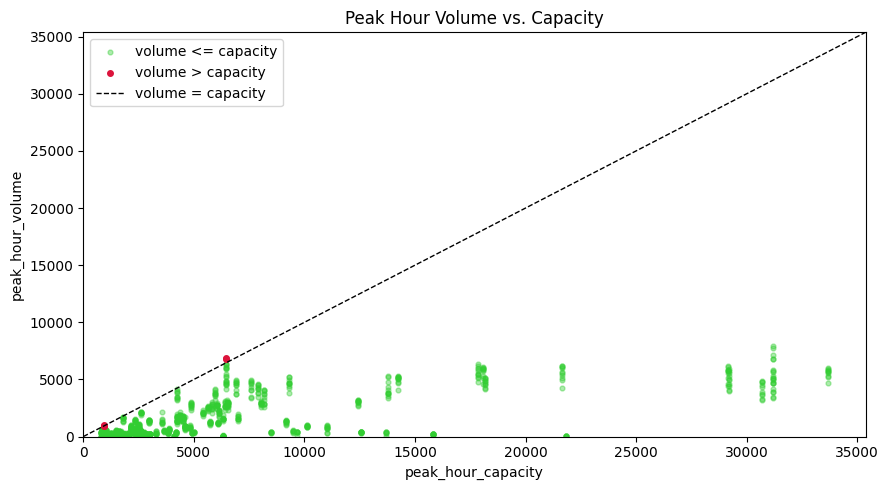

5 of 1964 rows have volume > capacity


In [9]:
over_capacity = df['peak_hour_volume'] > df['peak_hour_capacity']

fig, ax = plt.subplots()
ax.scatter(df.loc[~over_capacity, 'peak_hour_capacity'], df.loc[~over_capacity, 'peak_hour_volume'],
           s=12, color='limegreen', alpha=.4, label='volume <= capacity')
ax.scatter(df.loc[over_capacity, 'peak_hour_capacity'], df.loc[over_capacity, 'peak_hour_volume'],
           s=16, color='crimson', label='volume > capacity')
lims = [0, df[['peak_hour_capacity', 'peak_hour_volume']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='volume = capacity')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('peak_hour_capacity'); ax.set_ylabel('peak_hour_volume')
ax.legend()
ax.set_title('Peak Hour Volume vs. Capacity')
plt.tight_layout()
plt.show()

print(f"{over_capacity.sum()} of {len(df)} rows have volume > capacity")

## 5. Peak hour volume vs. capacity - before and after

The same volume-vs-capacity picture as section 4, but split by `before_or_after` so you can see how
observations move relative to the capacity line once a project opens. Points that cross from below
the `volume = capacity` line (before) to above it (after) are the ones worth a
second look.

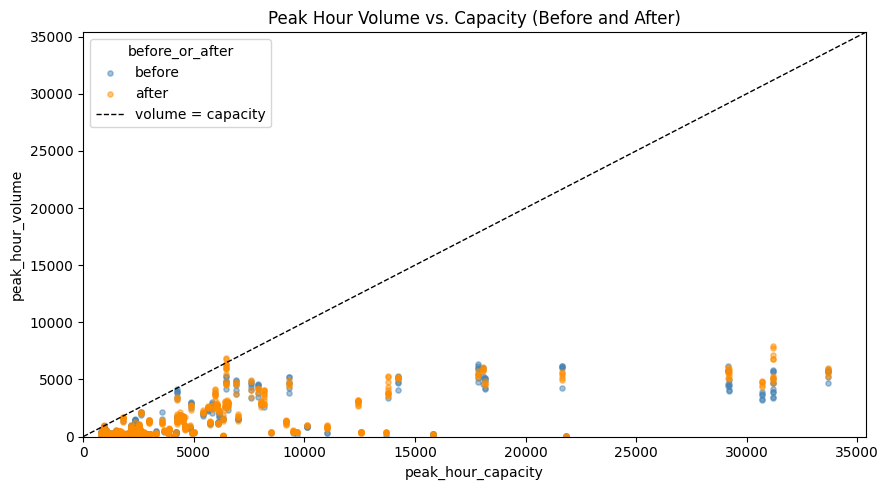

In [10]:
fig, ax = plt.subplots()

colors = {'before': 'steelblue', 'after': 'darkorange'}
for stage, color in colors.items():
    sub = df[df['before_or_after'] == stage]
    ax.scatter(sub['peak_hour_capacity'], sub['peak_hour_volume'],
               s=14, alpha=.5, color=color, label=stage)

lims = [0, df[['peak_hour_capacity', 'peak_hour_volume']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='volume = capacity')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('peak_hour_capacity')
ax.set_ylabel('peak_hour_volume')
ax.legend(title='before_or_after')
ax.set_title('Peak Hour Volume vs. Capacity (Before and After)')
plt.tight_layout()
plt.show()

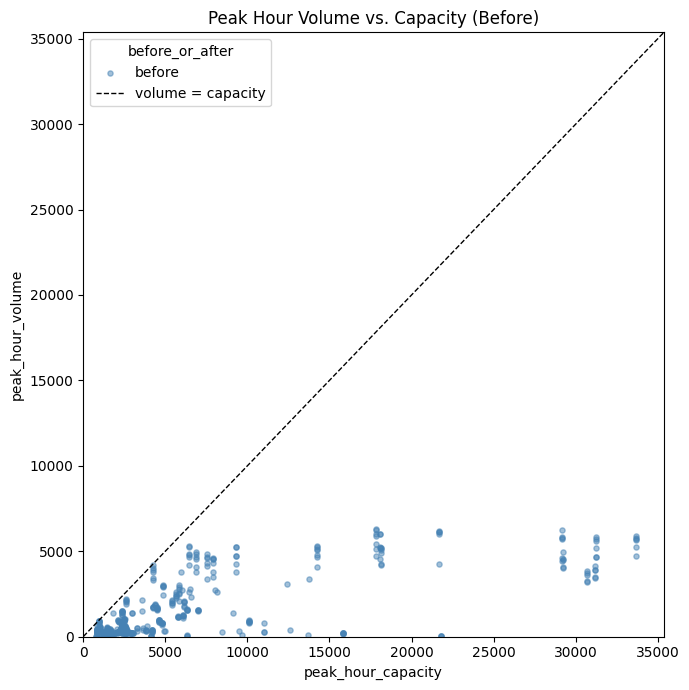

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

colors = {'before': 'steelblue'}
for stage, color in colors.items():
    sub = df[df['before_or_after'] == stage]
    ax.scatter(sub['peak_hour_capacity'], sub['peak_hour_volume'],
               s=14, alpha=.5, color=color, label=stage)

lims = [0, df[['peak_hour_capacity', 'peak_hour_volume']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='volume = capacity')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('peak_hour_capacity')
ax.set_ylabel('peak_hour_volume')
ax.legend(title='before_or_after')
ax.set_title('Peak Hour Volume vs. Capacity (Before)')
plt.tight_layout()
plt.show()

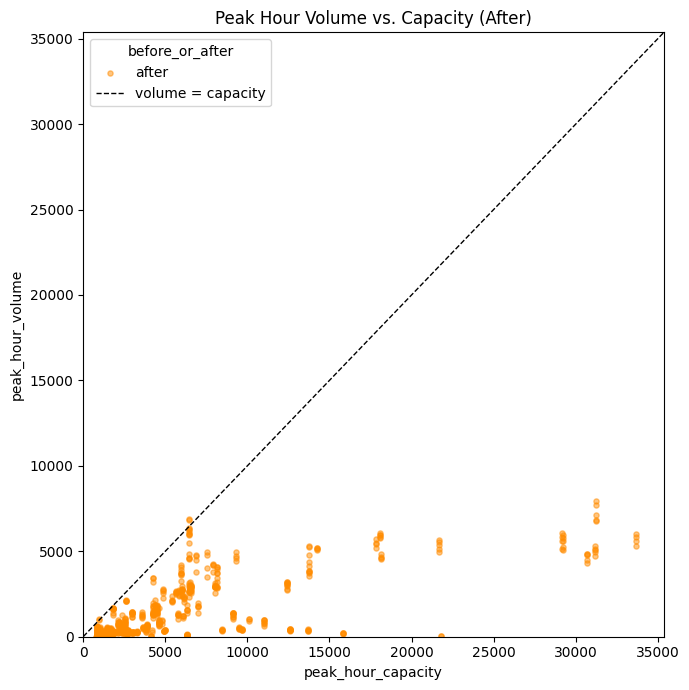

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))

colors = {'after': 'darkorange'}
for stage, color in colors.items():
    sub = df[df['before_or_after'] == stage]
    ax.scatter(sub['peak_hour_capacity'], sub['peak_hour_volume'],
               s=14, alpha=.5, color=color, label=stage)

lims = [0, df[['peak_hour_capacity', 'peak_hour_volume']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='volume = capacity')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('peak_hour_capacity')
ax.set_ylabel('peak_hour_volume')
ax.legend(title='before_or_after')
ax.set_title('Peak Hour Volume vs. Capacity (After)')
plt.tight_layout()
plt.show()

## 6. Before vs. after — traffic counts

For a capacity project, `observation_value` (AADT) should generally be higher *after* the project
opens than *before*. Projects where the after-value is lower than the before-value aren't
necessarily wrong, but they're worth a manual look.

In [13]:
before_after = (
    df.groupby(['project_id', 'before_or_after'])['observation_value']
      .mean()
      .unstack()
)
before_after['pct_change'] = (before_after['after'] / before_after['before'] - 1) * 100
before_after = before_after.sort_values('pct_change')
before_after

before_or_after,after,before,pct_change
project_id,,,
FM-0907,4955.298851,12795.666667,-61.273617
F-M-0436,9400.814815,16579.666667,-43.299133
FM-1314,15938.709091,25753.653846,-38.110882
FM-1408,3413.750000,5138.714286,-33.568013
FM-1405,33588.222222,49285.692308,-31.849954
...,...,...,...
FM-1410,4076.333333,NaN,NaN
FM-1603,13985.350000,NaN,NaN
FM-1803,NaN,65311.447761,NaN


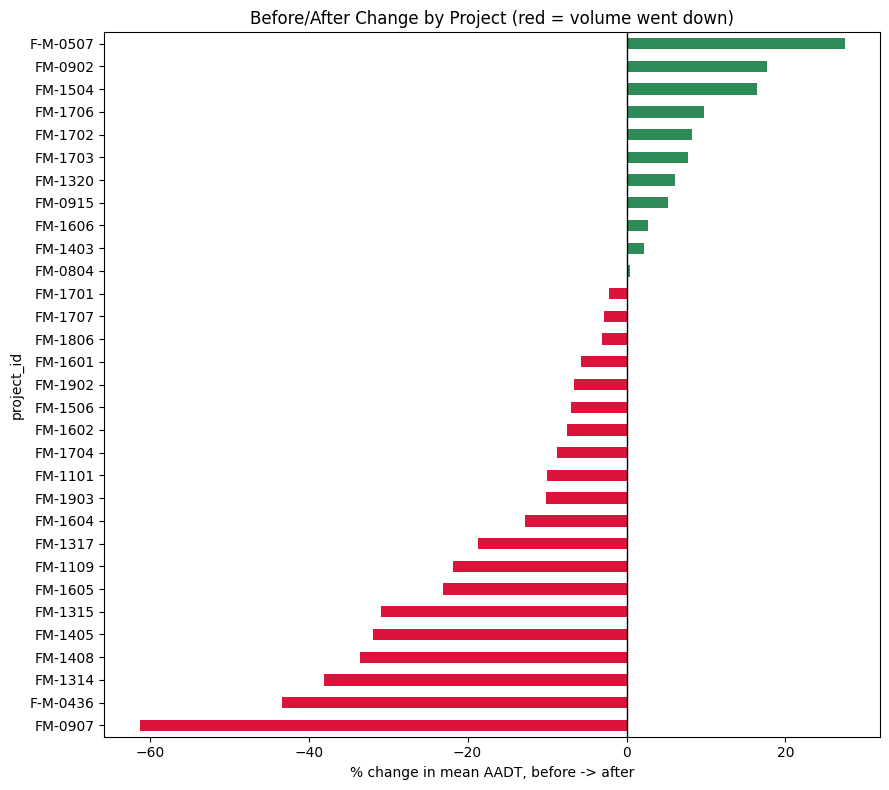

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_data = before_after['pct_change'].dropna()
colors = ['crimson' if v < 0 else 'seagreen' for v in plot_data]
plot_data.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('% change in mean AADT, before -> after')
ax.set_title('Before/After Change by Project (red = volume went down)')
plt.tight_layout()
plt.show()

## 7. Traffic counts, peak volume & capacity over time (per project)

For each project, this plots `observation_value` (AADT), `peak_hour_volume`, and `peak_hour_capacity`
over calendar year, with one line per count station (`poi_id`) for each metric. A vertical dashed line
marks the year the project actually opened (`date_open_actual`).

**Note on scale:** `observation_value` is a full-day count (AADT) while `peak_hour_volume` and
`peak_hour_capacity` are single-hour figures, so they sit on a much smaller scale and will look
close to flat at the bottom of the chart next to the AADT line for the same station.

In [15]:
def plot_project_station_timeseries(df, project_id, ax=None):
    """Line chart for one project: AADT, peak-hour volume, and peak-hour capacity per
    count station (poi_id), plotted against calendar year. Draws a vertical line at the
    project's actual open year."""
    proj = df[(df['project_id'] == project_id) & df['observation_date'].notna()].copy()
    if proj.empty:
        print(f"No dated observations for {project_id}")
        return None
    proj['year'] = proj['observation_date'].dt.year

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    stations = sorted(proj['poi_id'].unique())
    cmap = plt.get_cmap('tab10')
    for i, poi in enumerate(stations):
        color = cmap(i % 10)
        sub = proj[proj['poi_id'] == poi].sort_values('year')
        yearly = sub.groupby('year')[['observation_value', 'peak_hour_volume', 'peak_hour_capacity']].mean()

        ax.plot(yearly.index, yearly['observation_value'], color=color, marker='o',
                linewidth=1.5, label=f'POI {poi} - AADT count')
        if yearly['peak_hour_volume'].notna().any():
            ax.plot(yearly.index, yearly['peak_hour_volume'], color=color, marker='s',
                    linestyle='--', alpha=.7, linewidth=1, label=f'POI {poi} - peak hr volume')
        if yearly['peak_hour_capacity'].notna().any():
            ax.plot(yearly.index, yearly['peak_hour_capacity'], color=color, linestyle=':',
                    alpha=.5, linewidth=1, label=f'POI {poi} - peak hr capacity')

    open_dates = proj['date_open_actual'].dropna()
    if len(open_dates):
        open_year = open_dates.iloc[0].year
        ax.axvline(open_year, color='black', linestyle='--', linewidth=1.5, label=f'opened {open_year}')

    ax.set_xlabel('Year')
    ax.set_ylabel('AADT')
    ax.set_title(f'{project_id}: Traffic Counts, Peak Volume & Capacity by Station')
    ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1))
    return ax

32 of 62 projects have counts spanning their opening year


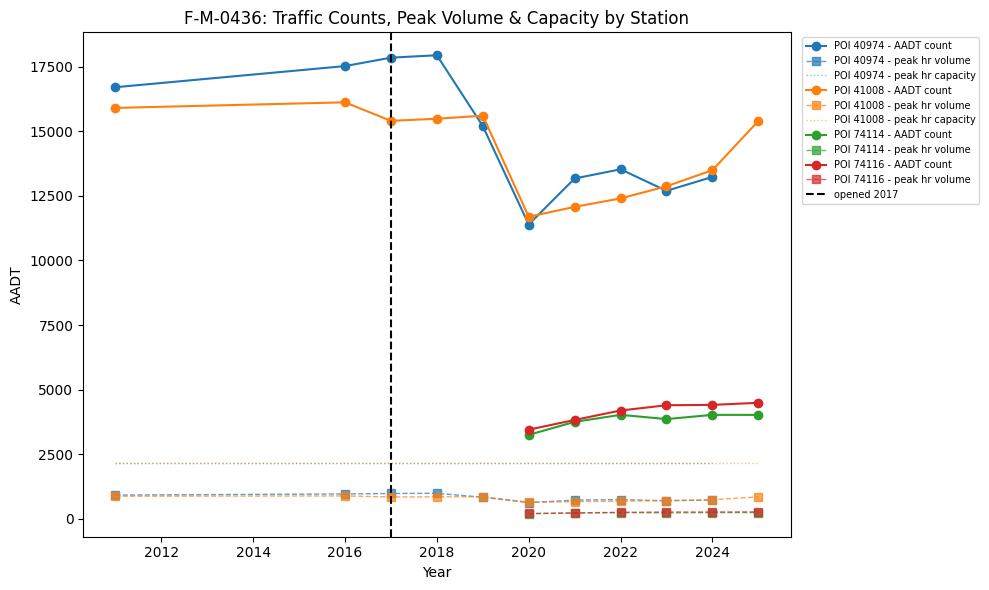

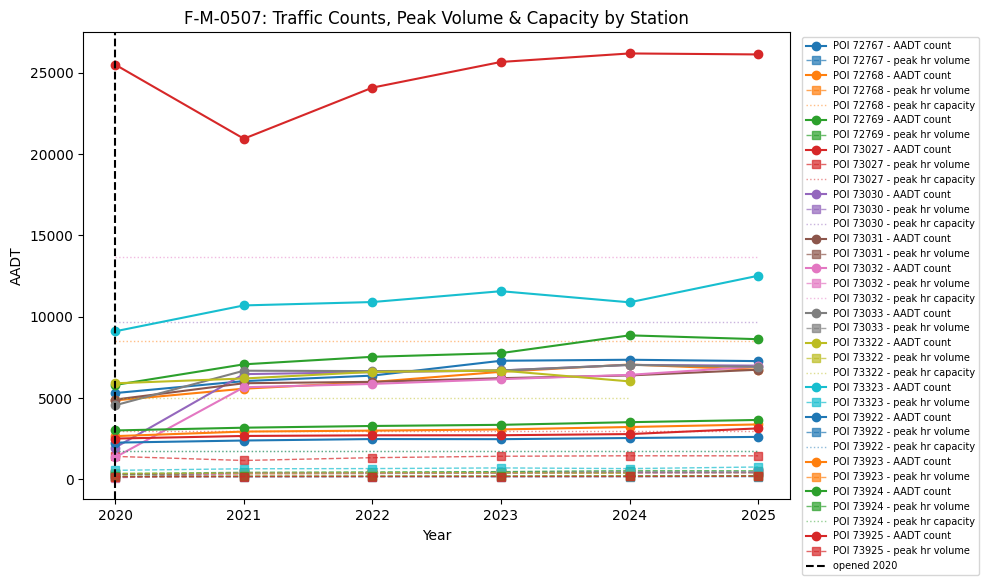

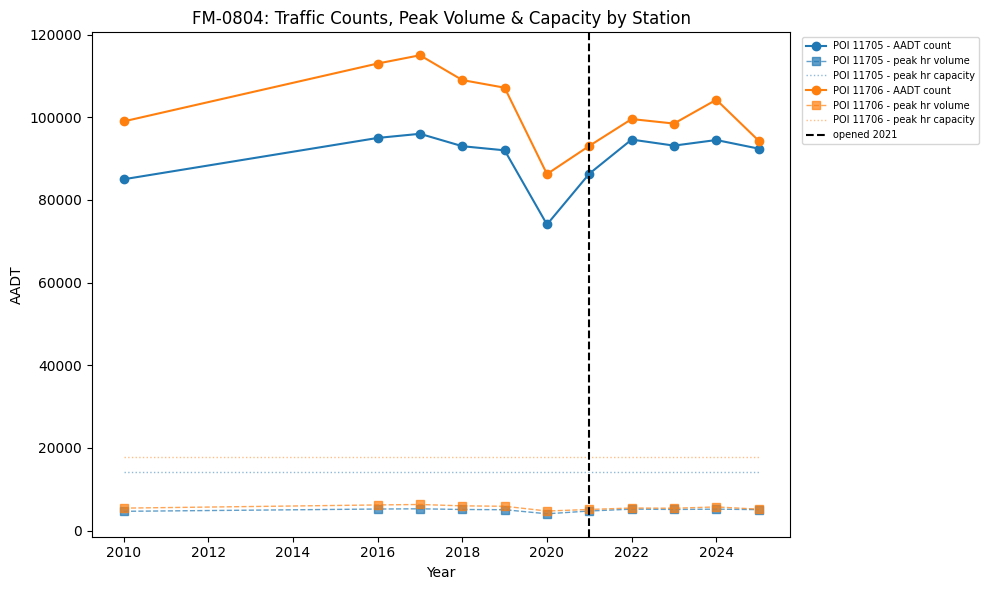

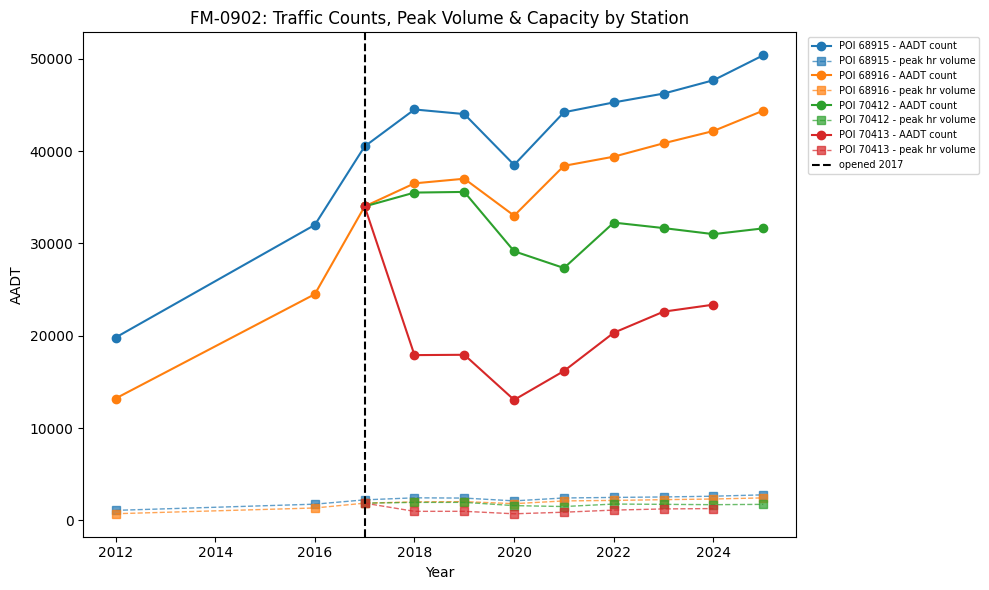

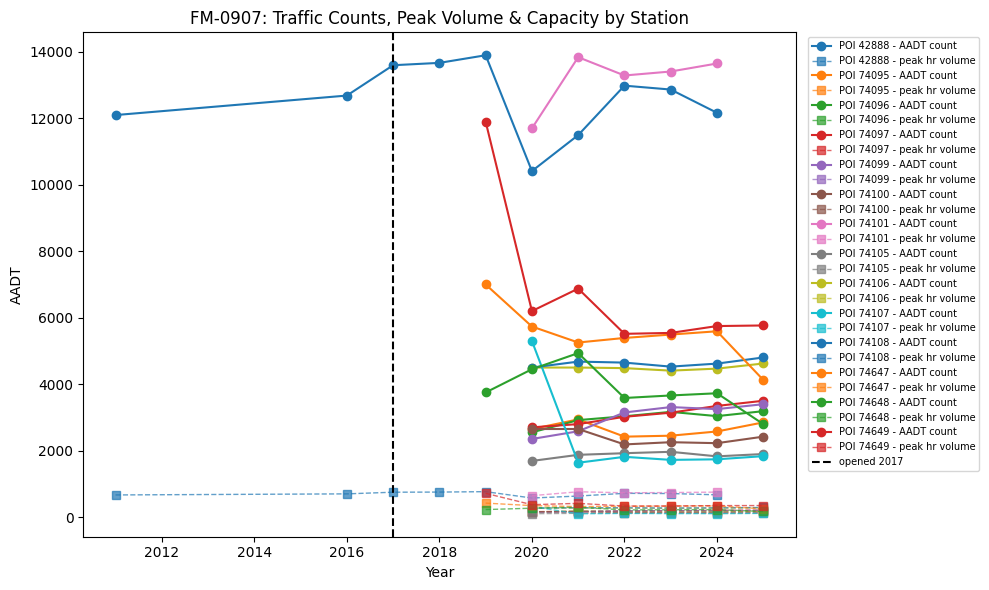

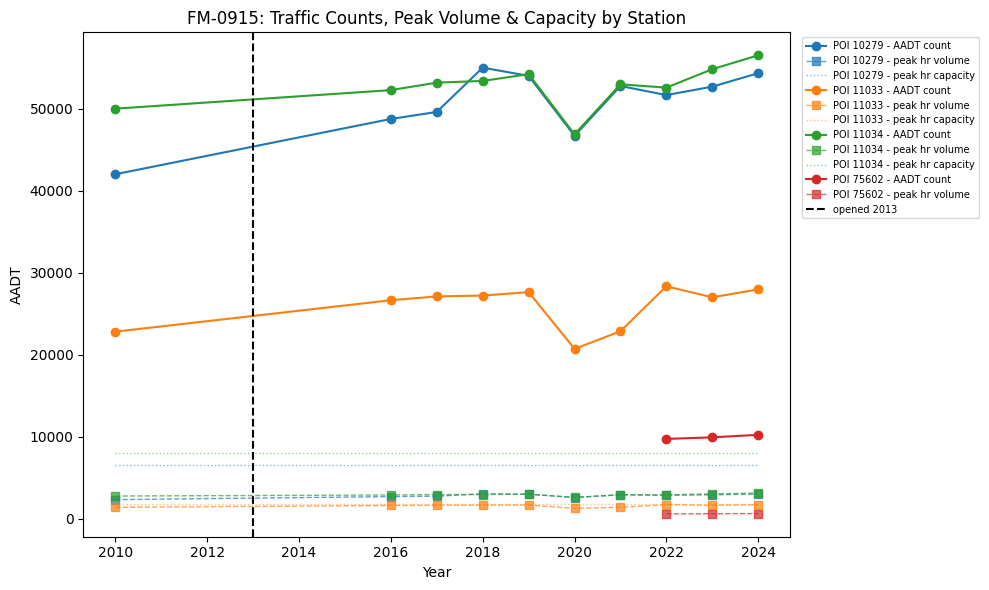

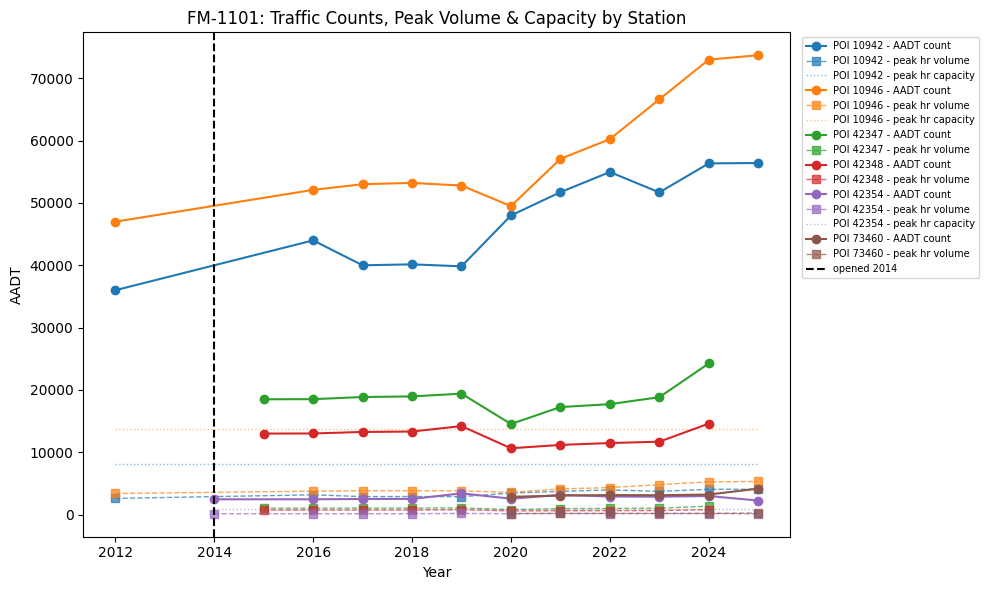

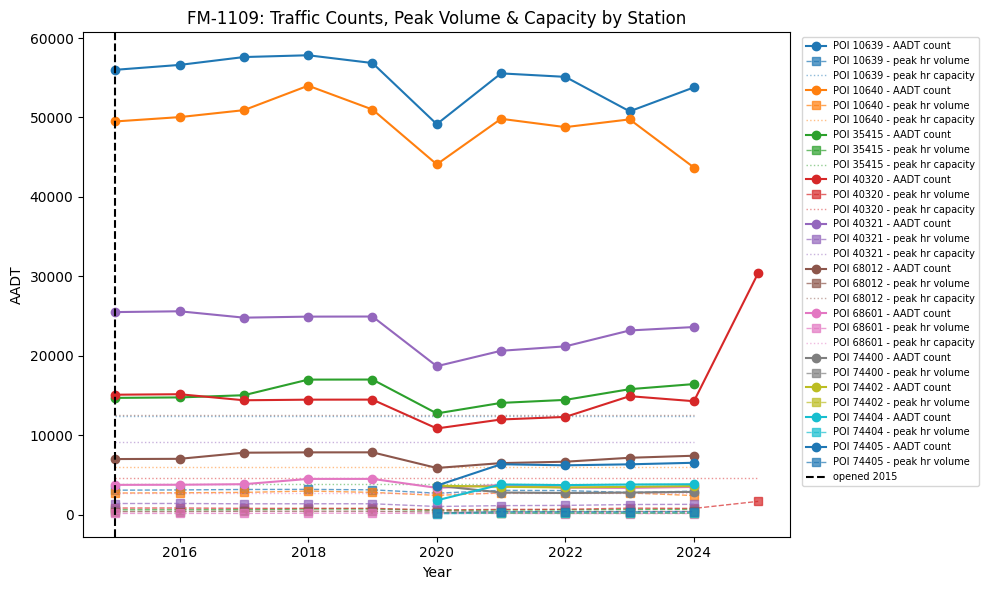

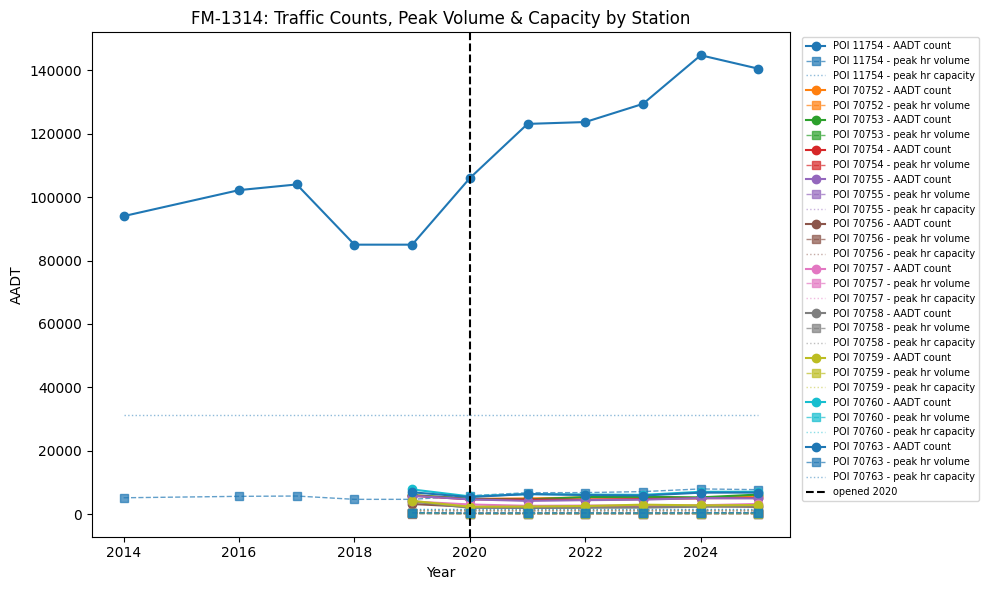

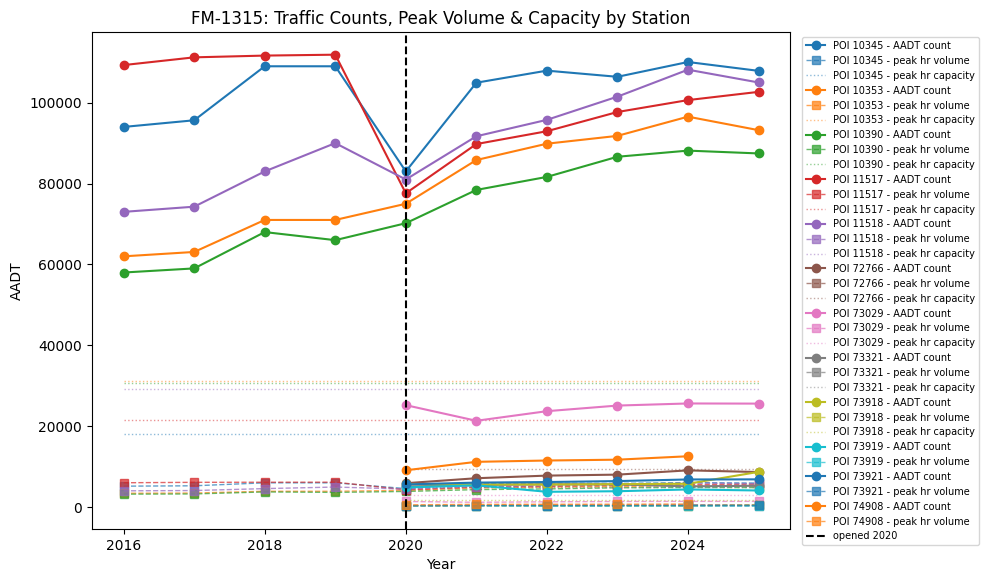

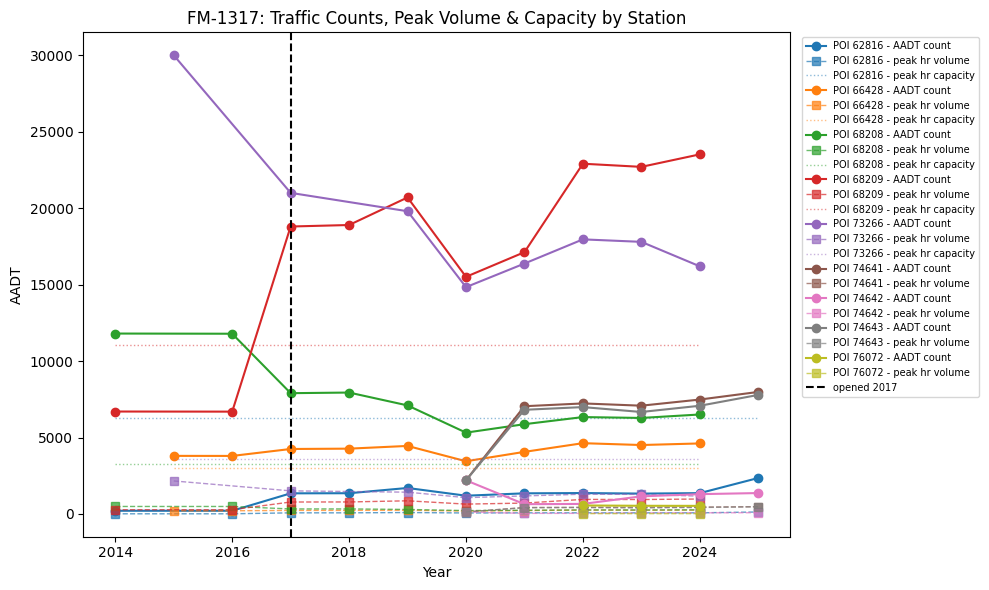

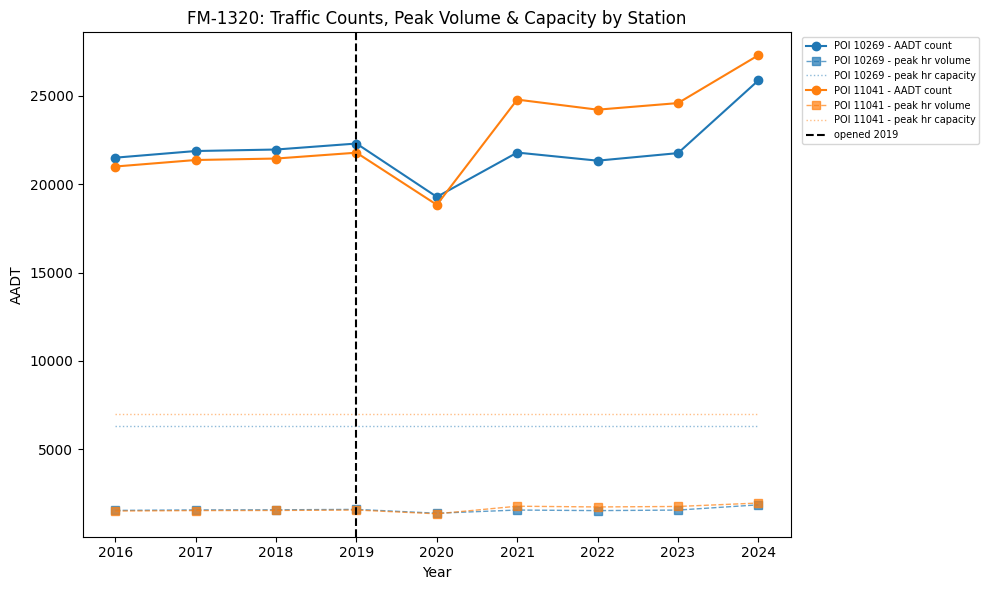

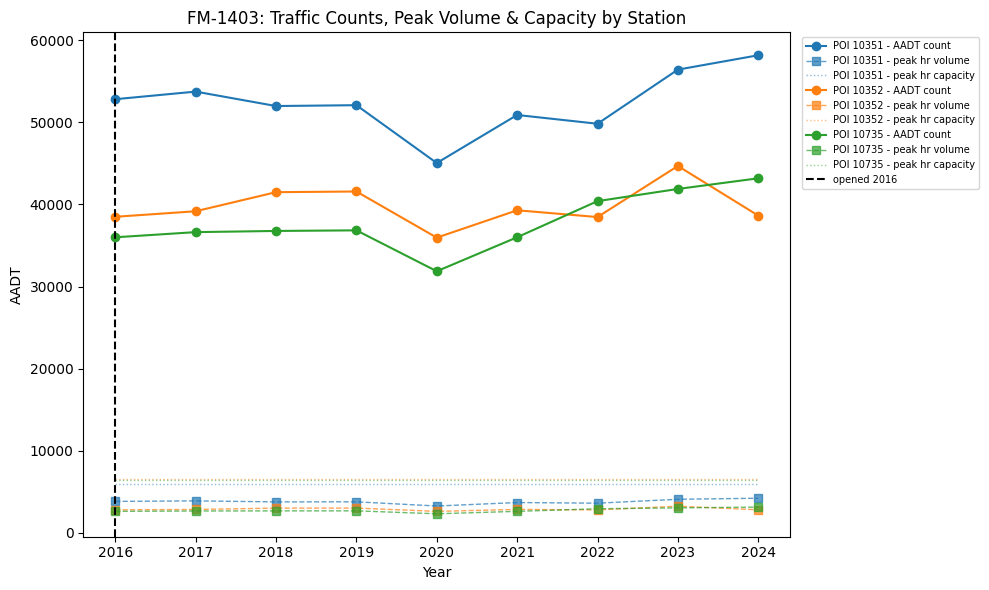

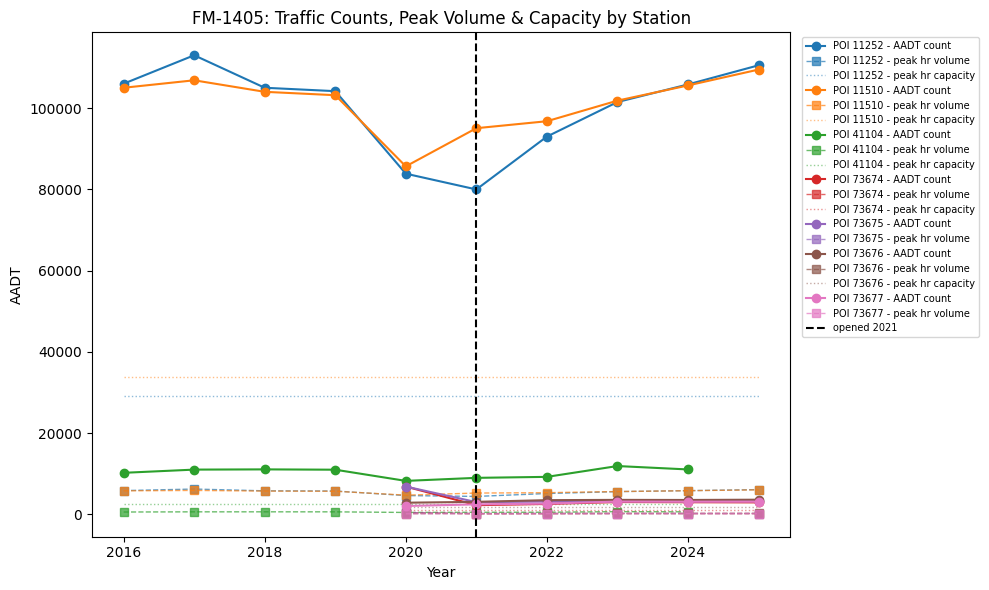

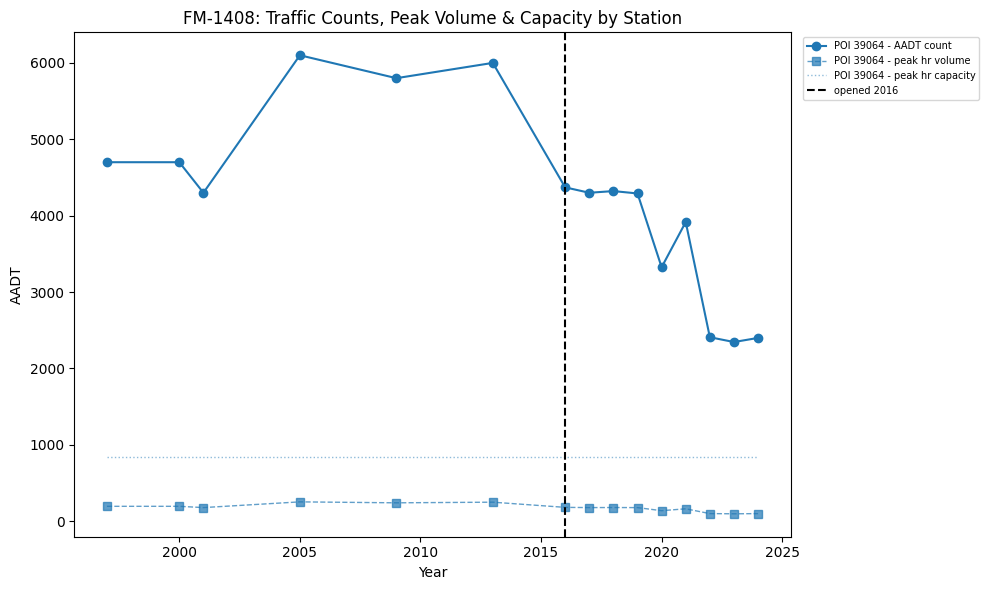

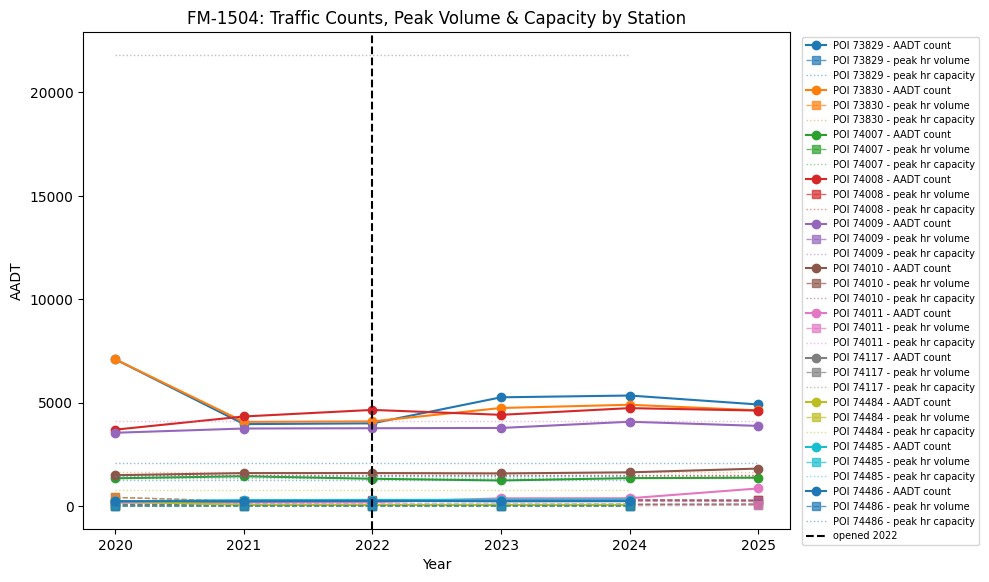

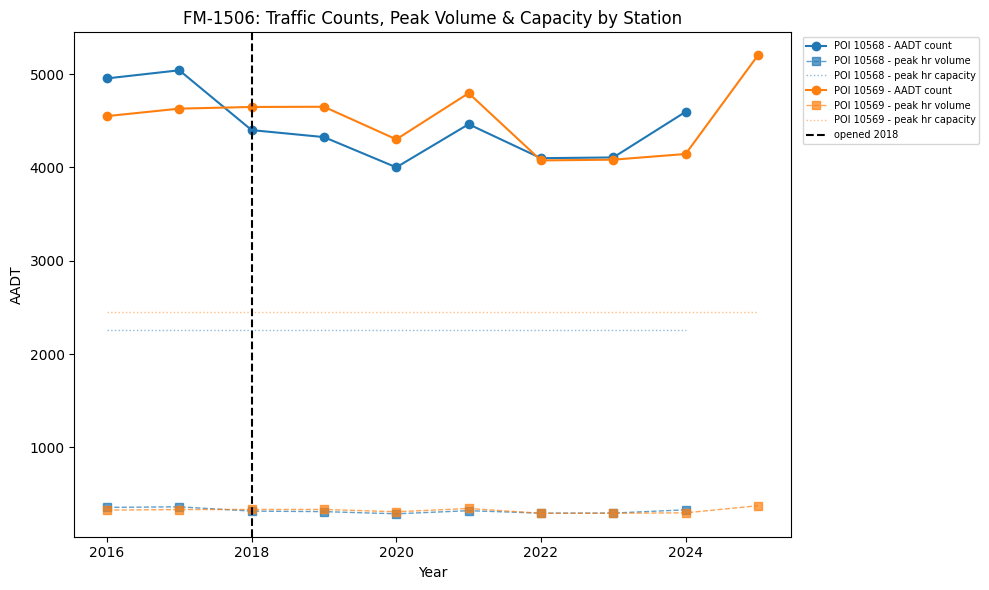

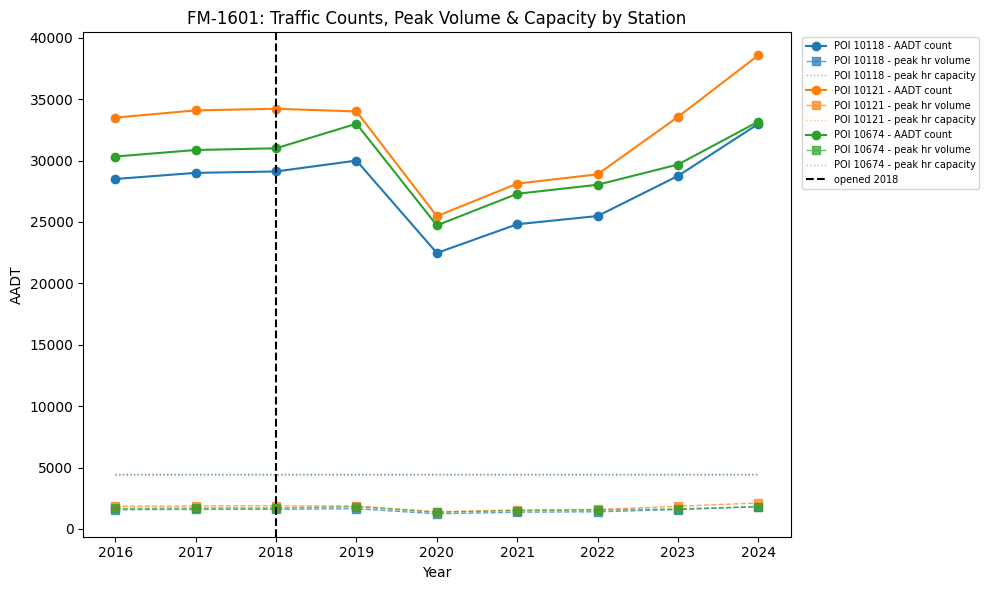

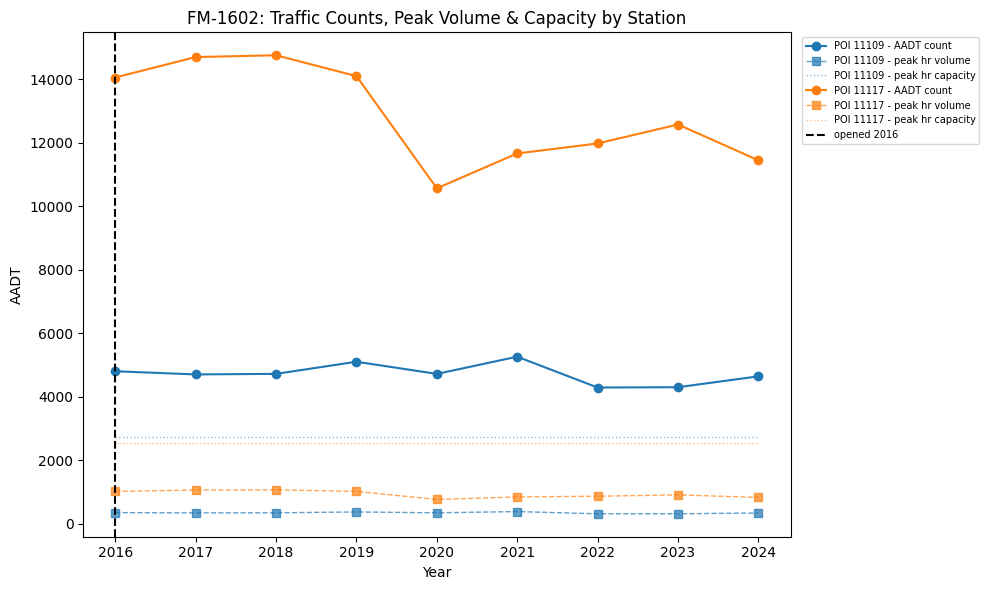

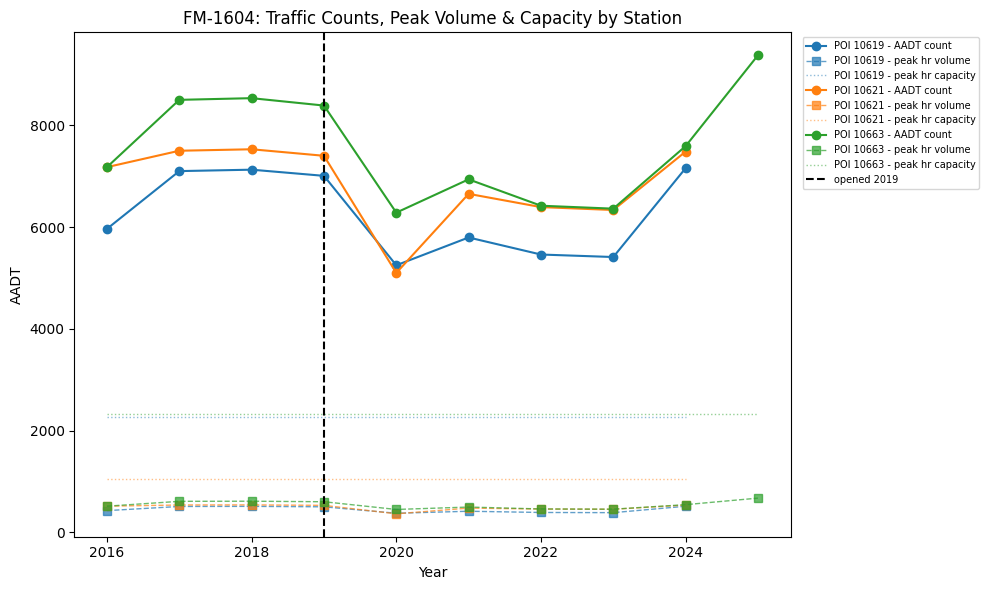

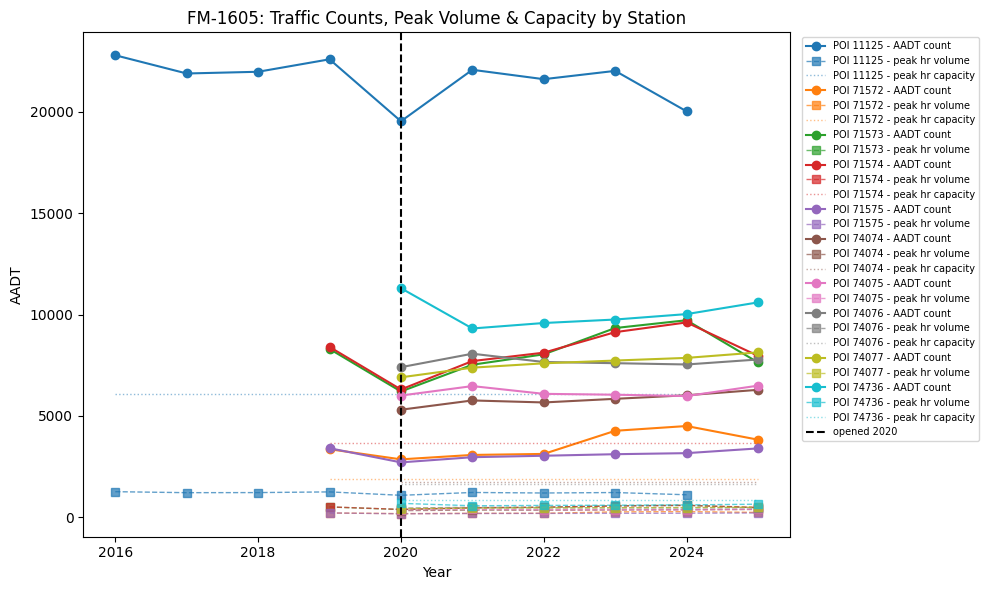

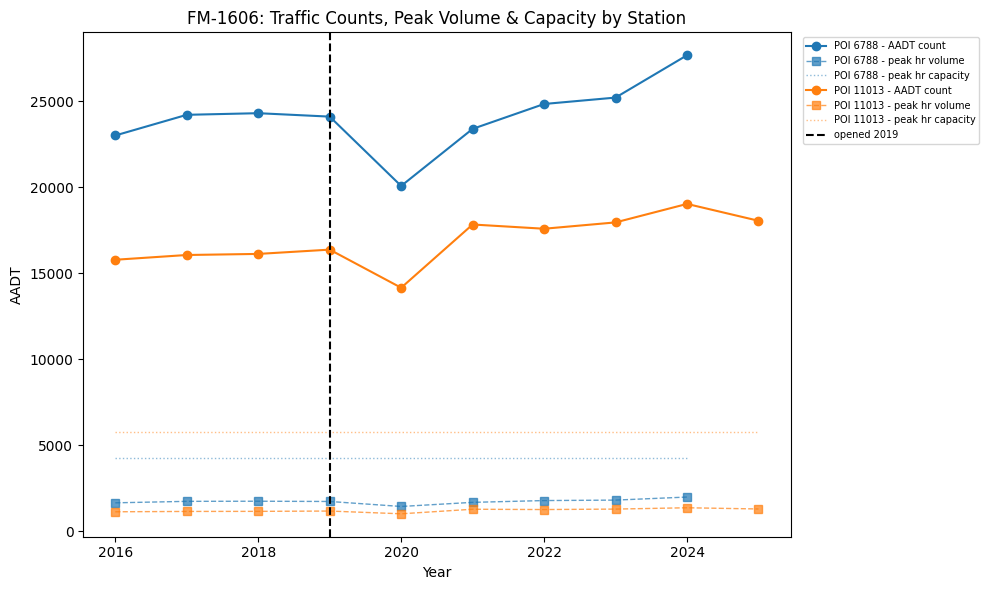

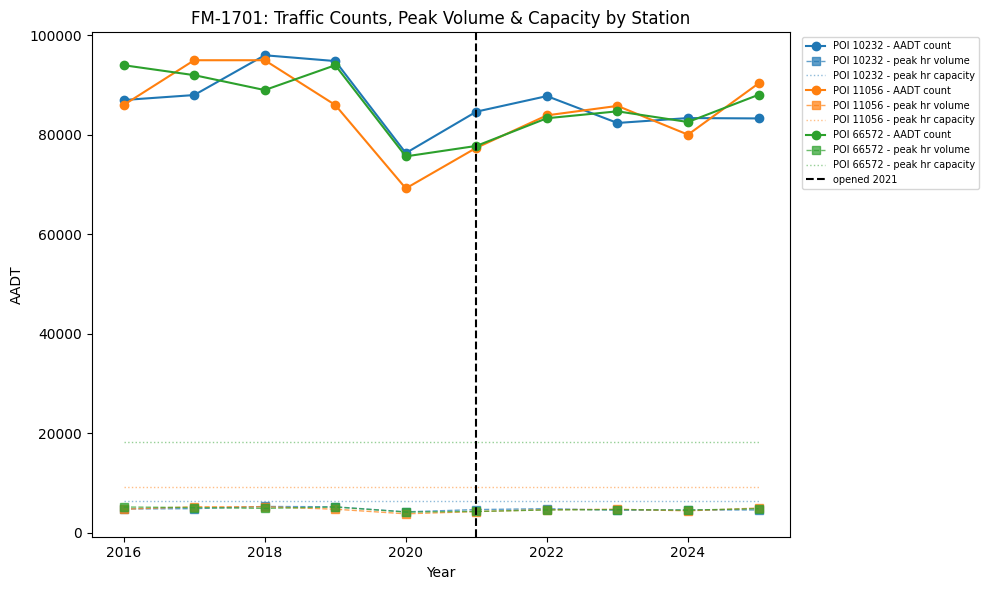

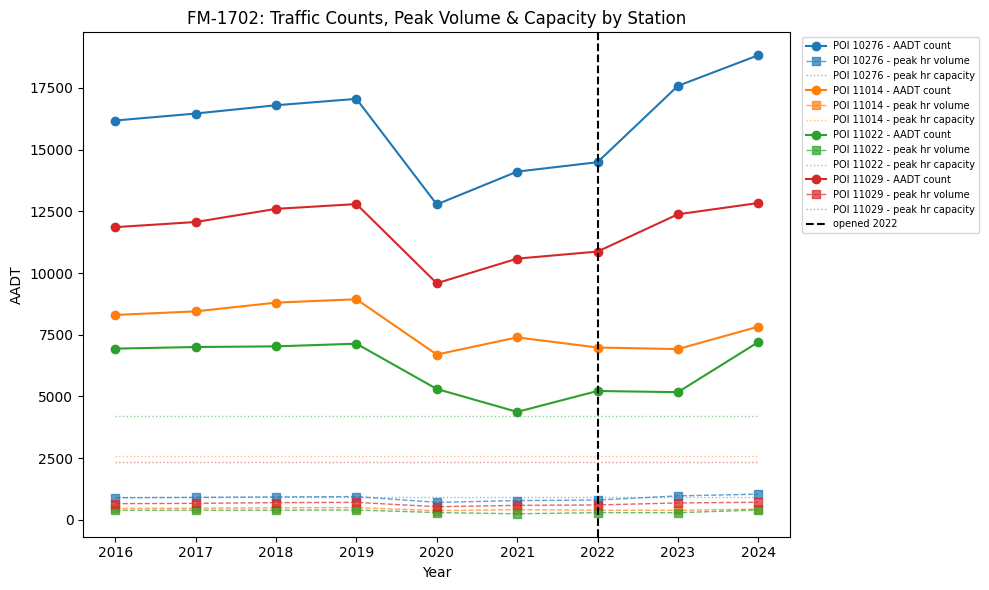

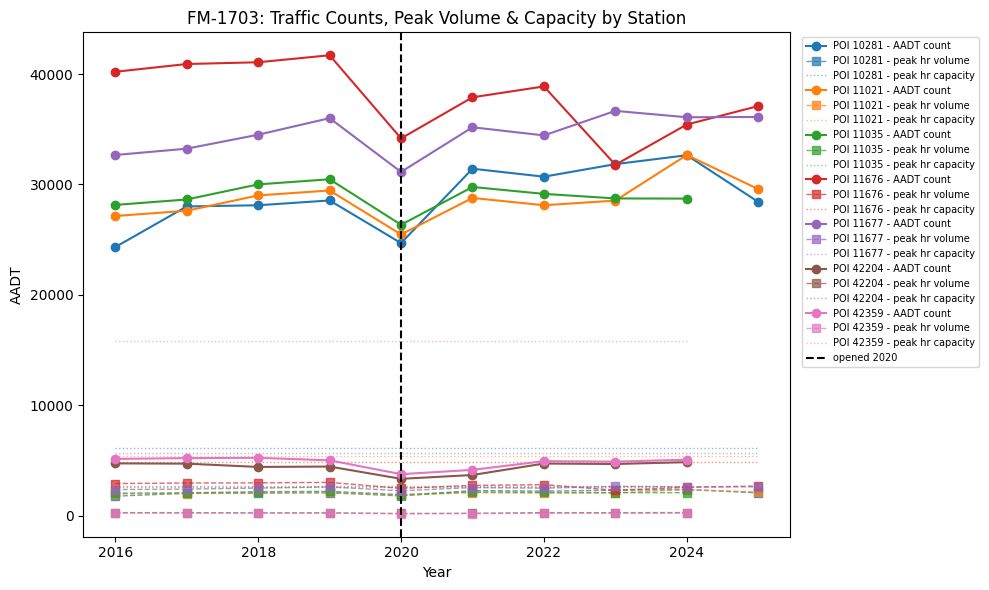

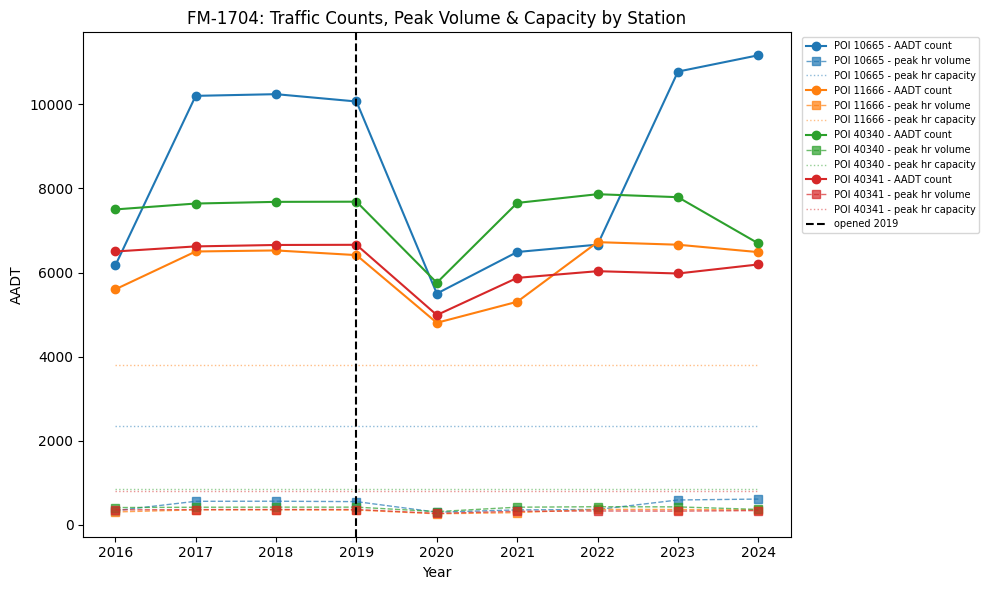

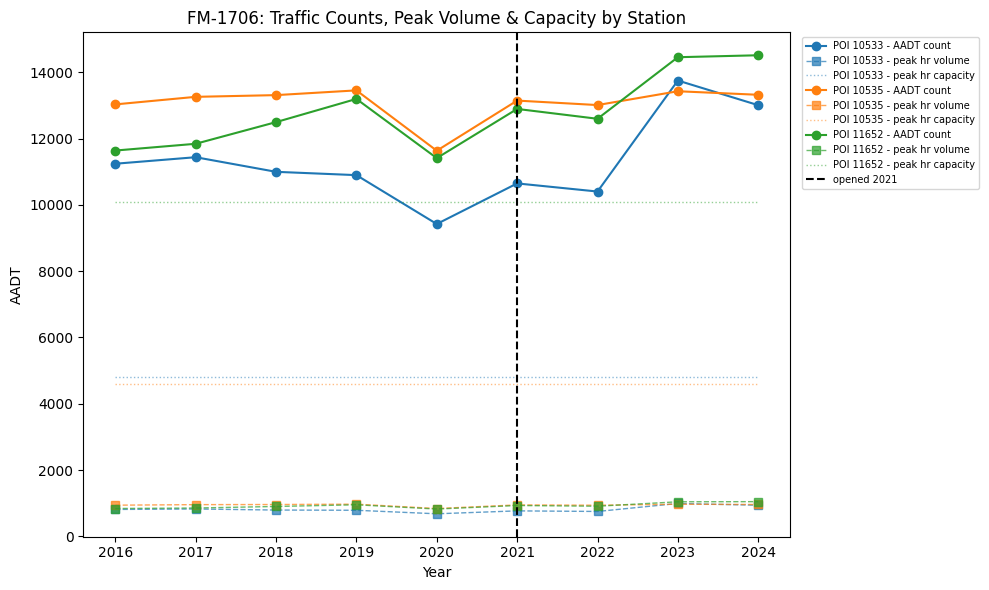

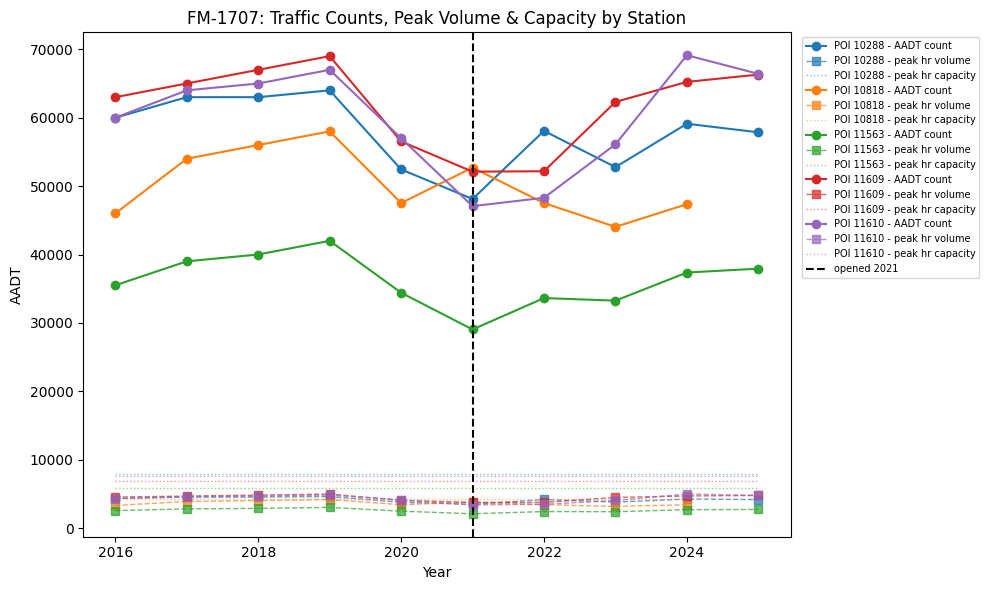

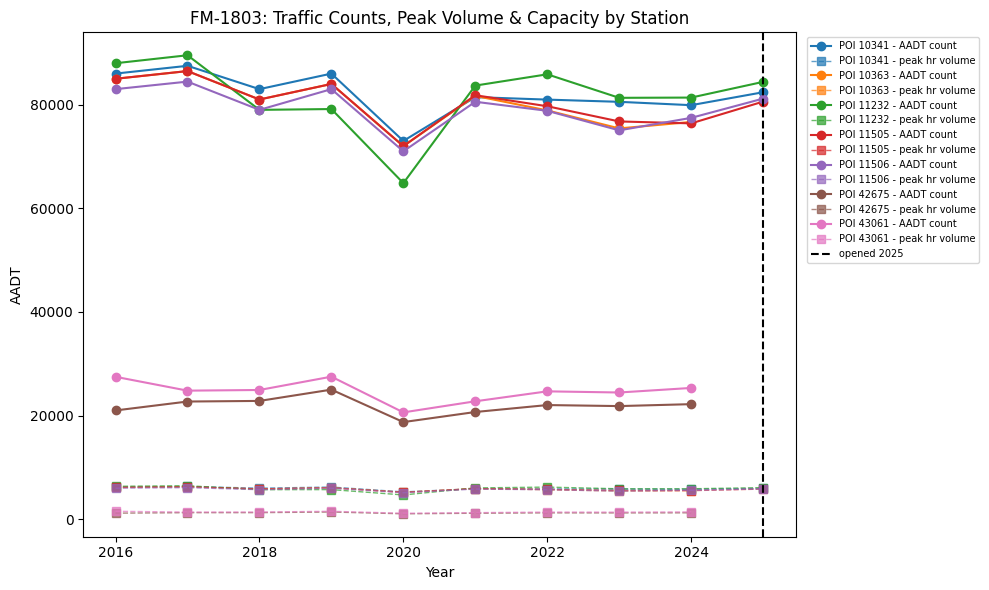

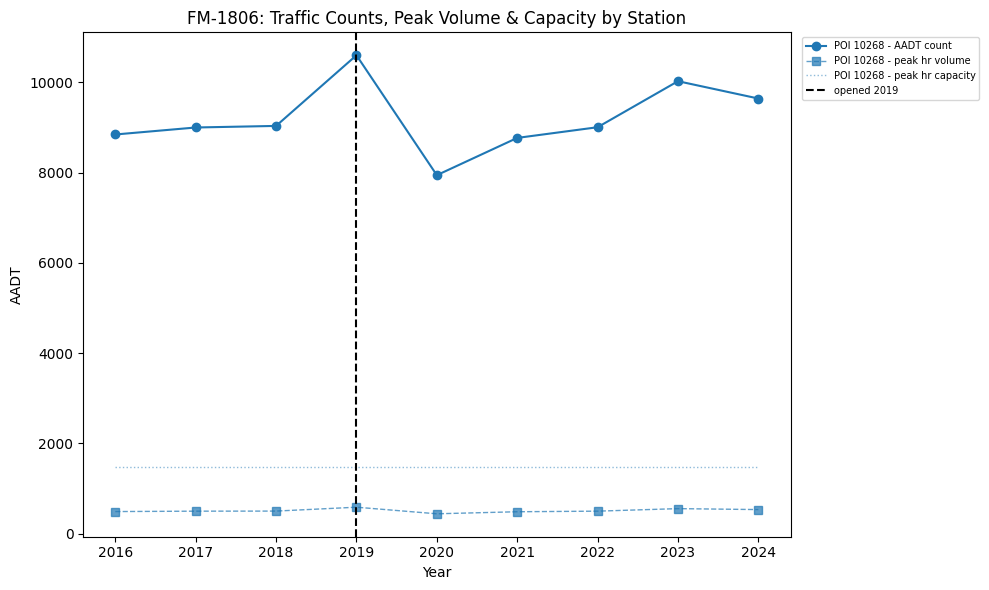

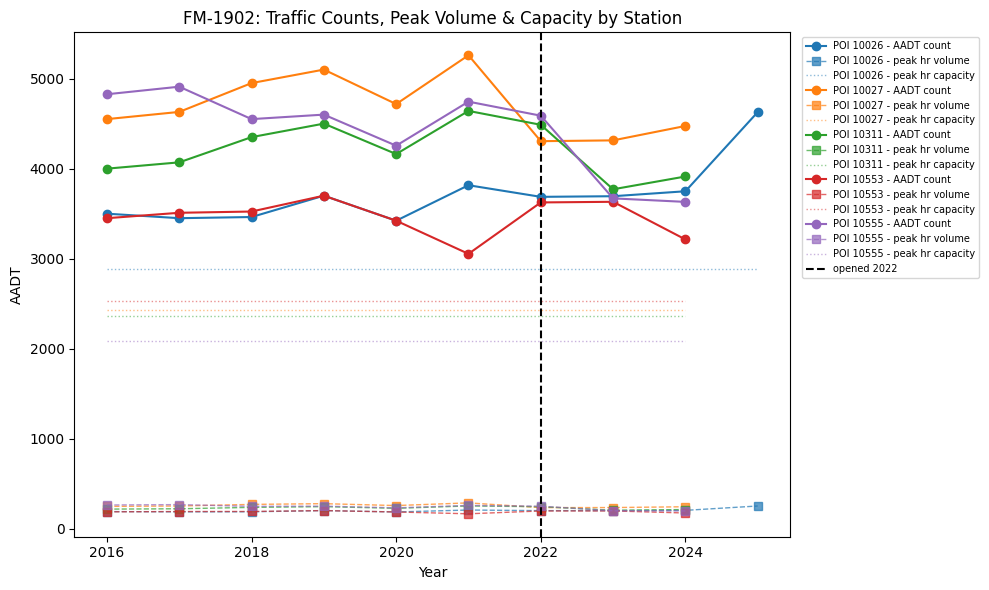

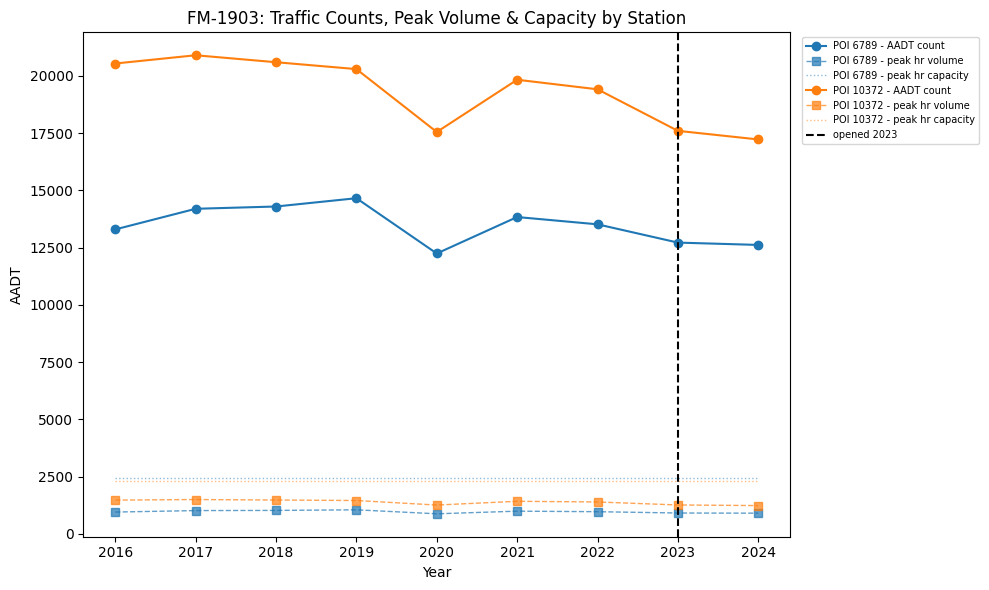

In [16]:
# Only plot projects whose observed count years actually span the opening year
def _spans_open_year(df, project_id):
    proj = df[(df['project_id'] == project_id) & df['observation_date'].notna()]
    if proj.empty:
        return False
    open_dates = proj['date_open_actual'].dropna()
    if not len(open_dates):
        return False
    open_year = open_dates.iloc[0].year
    years = proj['observation_date'].dt.year
    return years.min() <= open_year <= years.max()

PROJECTS_TO_PLOT = [pid for pid in sorted(df['project_id'].unique()) if _spans_open_year(df, pid)]
print(f"{len(PROJECTS_TO_PLOT)} of {df['project_id'].nunique()} projects have counts spanning their opening year")

for pid in PROJECTS_TO_PLOT:
    fig, ax = plt.subplots(figsize=(10, 6))
    result = plot_project_station_timeseries(df, pid, ax=ax)
    if result is None:
        plt.close(fig)  # no data for this project - skip the chart
        continue
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## 8. AADT vs. years from open (all projects)

The same traffic-count trend as section 7, but re-centered on each project's own opening year
(`years_from_open`) instead of the calendar year, and overlaid across all projects so their timelines
line up at the opening (`years_from_open = 0`, marked with the vertical dashed line). Each line is
one project's average AADT across its stations for that year offset.

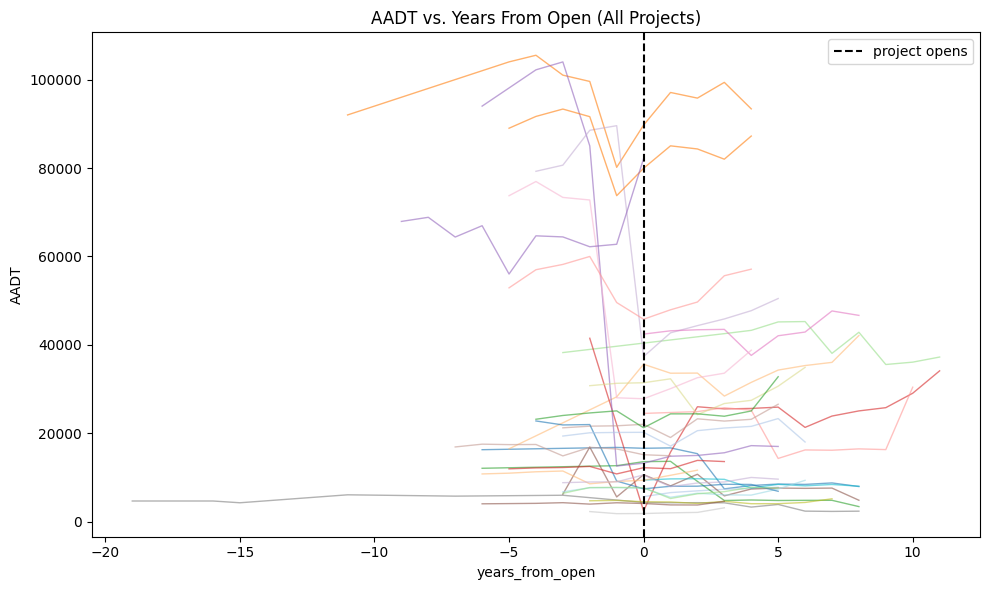

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

project_ids = [
    pid for pid in sorted(df['project_id'].unique())
    if (df.loc[df['project_id'] == pid, 'years_from_open'].min() <= 0
        <= df.loc[df['project_id'] == pid, 'years_from_open'].max())
]
cmap = plt.get_cmap('tab20')

for i, pid in enumerate(project_ids):
    sub = df[df['project_id'] == pid]
    yearly = sub.groupby('years_from_open')['observation_value'].mean().dropna()
    if len(yearly) < 2:
        continue
    ax.plot(yearly.index, yearly.values, color=cmap(i % 20), alpha=.6, linewidth=1)

ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='project opens')
ax.set_xlabel('years_from_open')
ax.set_ylabel('AADT')
ax.set_title('AADT vs. Years From Open (All Projects)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. % change in AADT vs. years from open (all projects)

Same idea as section 8, but each project's AADT is converted to a % change relative to its own
pre-project baseline (the average AADT across all observations with `years_from_open < 0`), so
projects with very different traffic volumes can be compared on the same y-axis. The vertical dashed
line marks the opening year; the horizontal line at 0% marks the baseline itself.

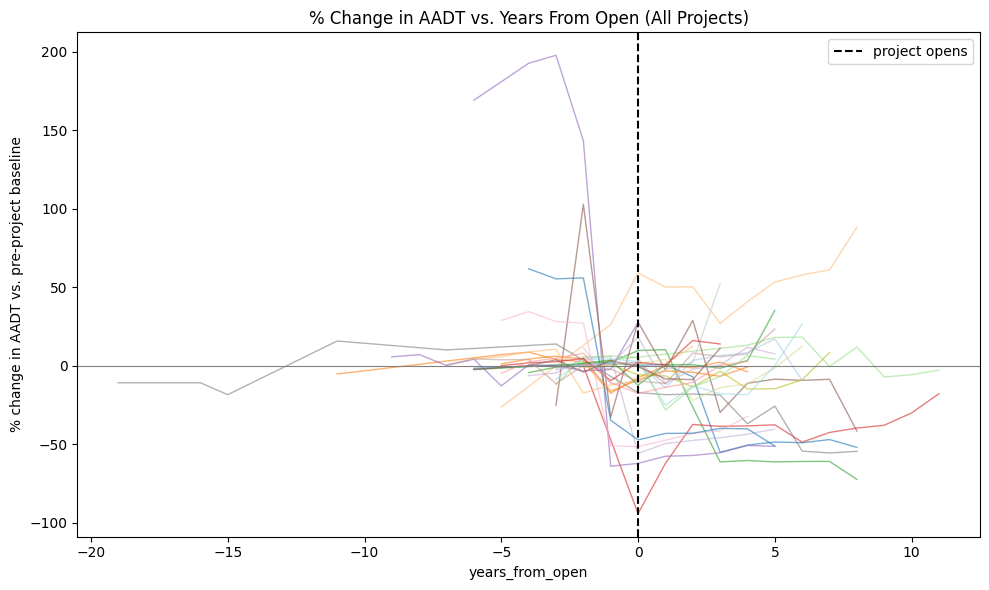

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, pid in enumerate(project_ids):
    sub = df[df['project_id'] == pid]
    yearly = sub.groupby('years_from_open')['observation_value'].mean().dropna()
    baseline = sub.loc[sub['years_from_open'] < 0, 'observation_value'].mean()
    if pd.isna(baseline) or baseline == 0 or len(yearly) < 2:
        continue
    pct = (yearly / baseline - 1) * 100
    ax.plot(pct.index, pct.values, color=cmap(i % 20), alpha=.6, linewidth=1)

ax.axhline(0, color='gray', linewidth=.8)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='project opens')
ax.set_xlabel('years_from_open')
ax.set_ylabel('% change in AADT vs. pre-project baseline')
ax.set_title('% Change in AADT vs. Years From Open (All Projects)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Volume-to-capacity ratio over time (per project)

For each project, plots `peak_hour_volume / peak_hour_capacity` over calendar year, with one line per
count station. A ratio above 1 (marked with the red dotted line) means the station's peak-hour volume
exceeds its computed peak-hour capacity.

In [19]:
def plot_project_vc_ratio(df, project_id, ax=None):
    """Line chart for one project: volume/capacity ratio per count station (poi_id) over
    calendar year. Draws a vertical line at the project's actual open year and a horizontal
    reference line at ratio = 1 (volume = capacity)."""
    proj = df[(df['project_id'] == project_id) & df['observation_date'].notna()].copy()
    proj = proj.dropna(subset=['peak_hour_volume', 'peak_hour_capacity'])
    proj = proj[proj['peak_hour_capacity'] > 0]
    if proj.empty:
        print(f"No usable volume/capacity data for {project_id}")
        return None
    proj['year'] = proj['observation_date'].dt.year
    proj['vc_ratio'] = proj['peak_hour_volume'] / proj['peak_hour_capacity']

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    stations = sorted(proj['poi_id'].unique())
    cmap = plt.get_cmap('tab10')
    for i, poi in enumerate(stations):
        sub = proj[proj['poi_id'] == poi].sort_values('year')
        yearly = sub.groupby('year')['vc_ratio'].mean()
        ax.plot(yearly.index, yearly.values, color=cmap(i % 10), marker='o', label=f'POI {poi}')

    open_dates = proj['date_open_actual'].dropna()
    if len(open_dates):
        open_year = open_dates.iloc[0].year
        ax.axvline(open_year, color='black', linestyle='--', linewidth=1.5, label=f'opened {open_year}')

    ax.axhline(1, color='crimson', linestyle=':', linewidth=1, label='volume = capacity')
    ax.set_xlabel('Year')
    ax.set_ylabel('Volume / Capacity')
    ax.set_title(f'{project_id}: Volume-to-Capacity Ratio by Station')
    ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
    return ax

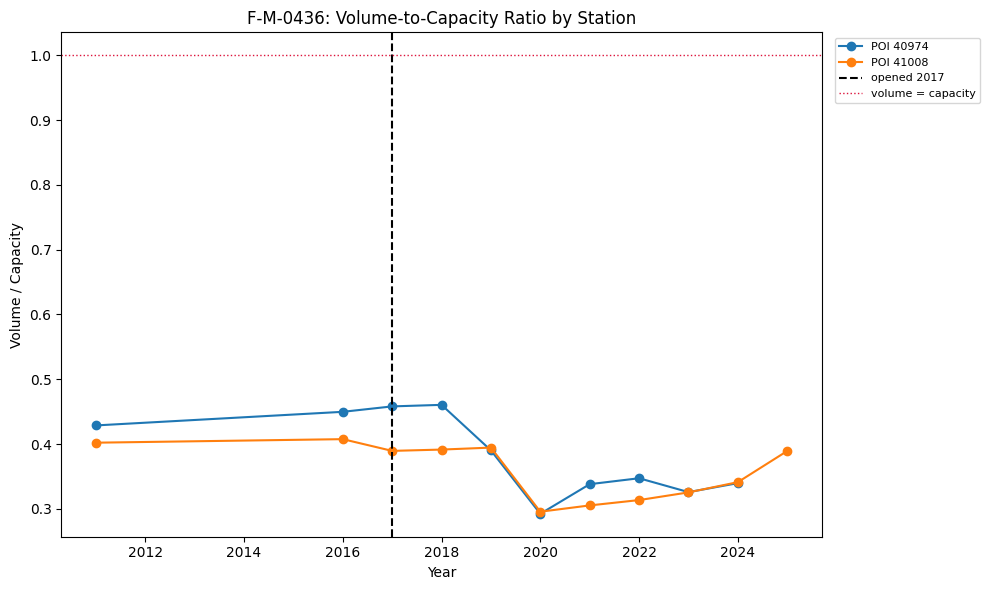

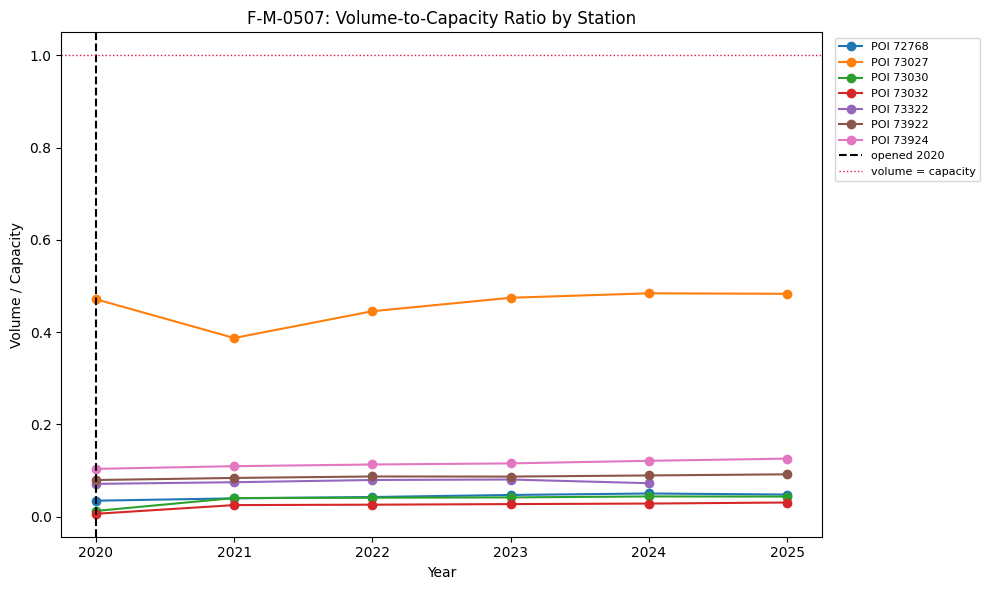

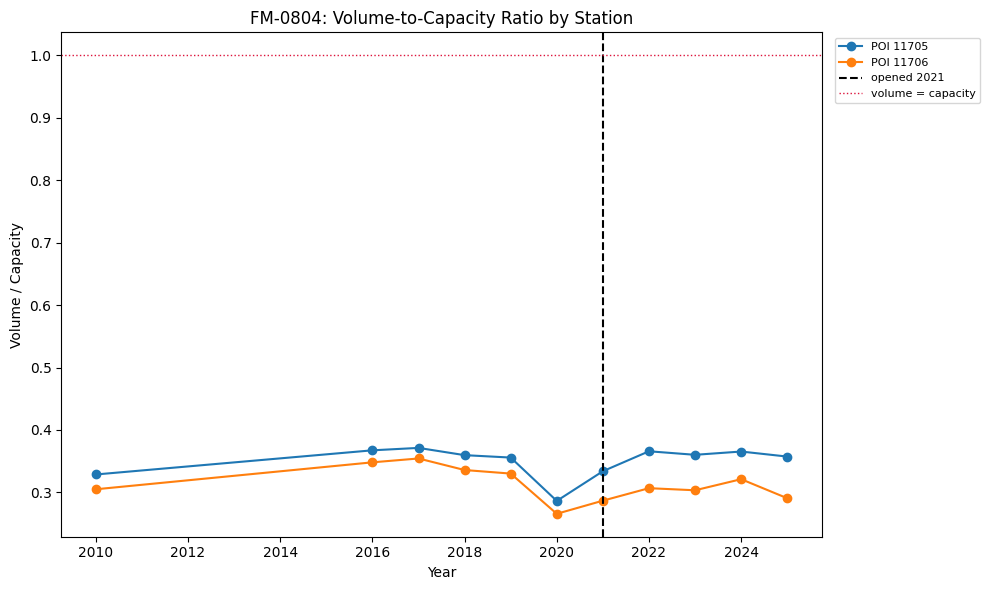

No usable volume/capacity data for FM-0902
No usable volume/capacity data for FM-0907


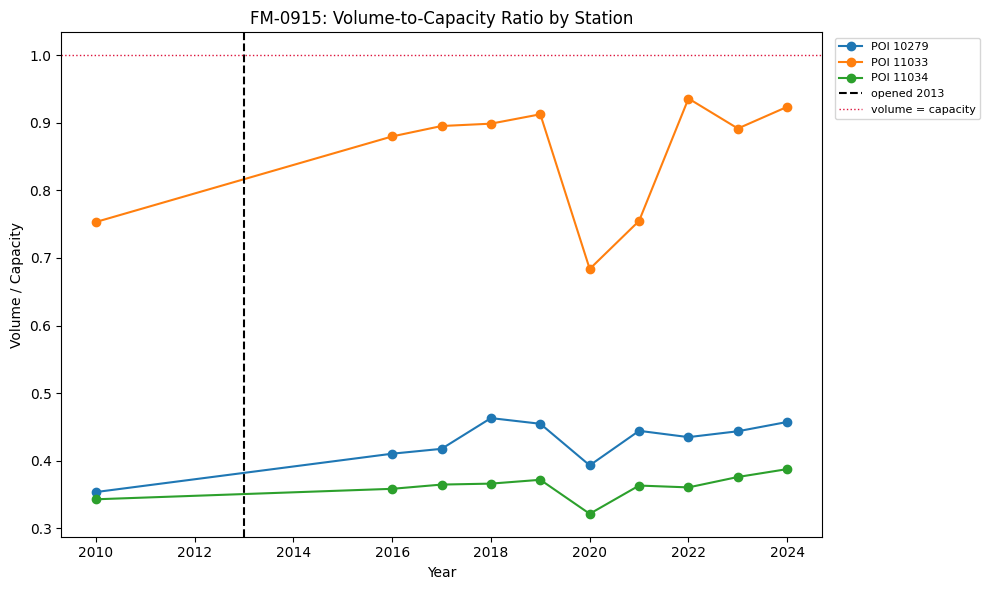

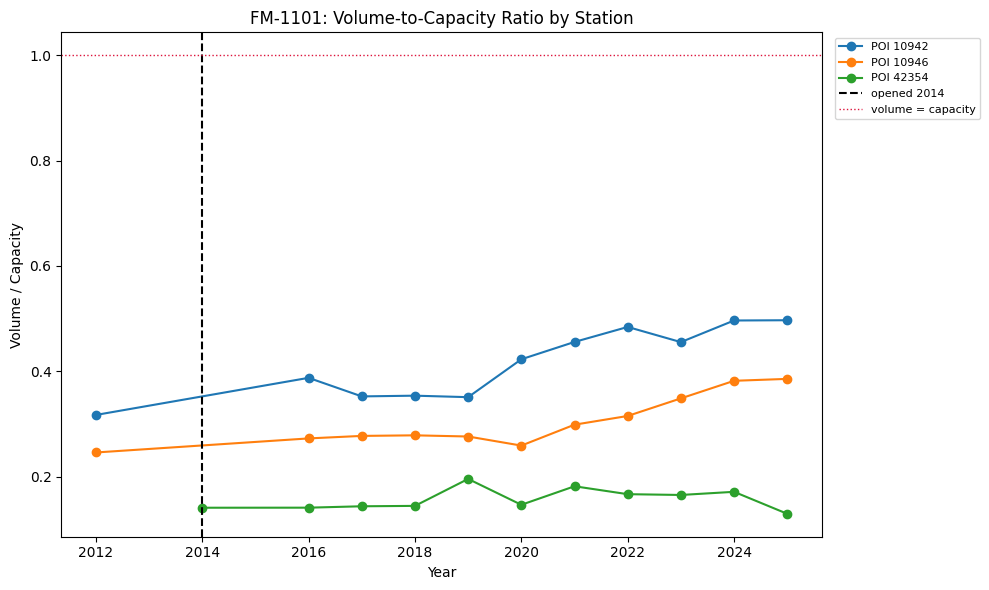

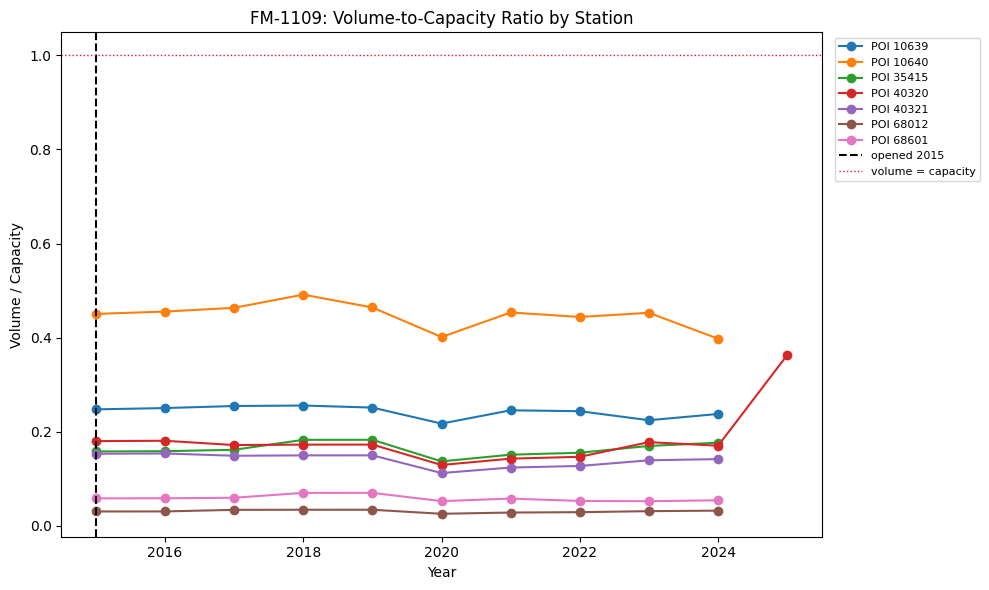

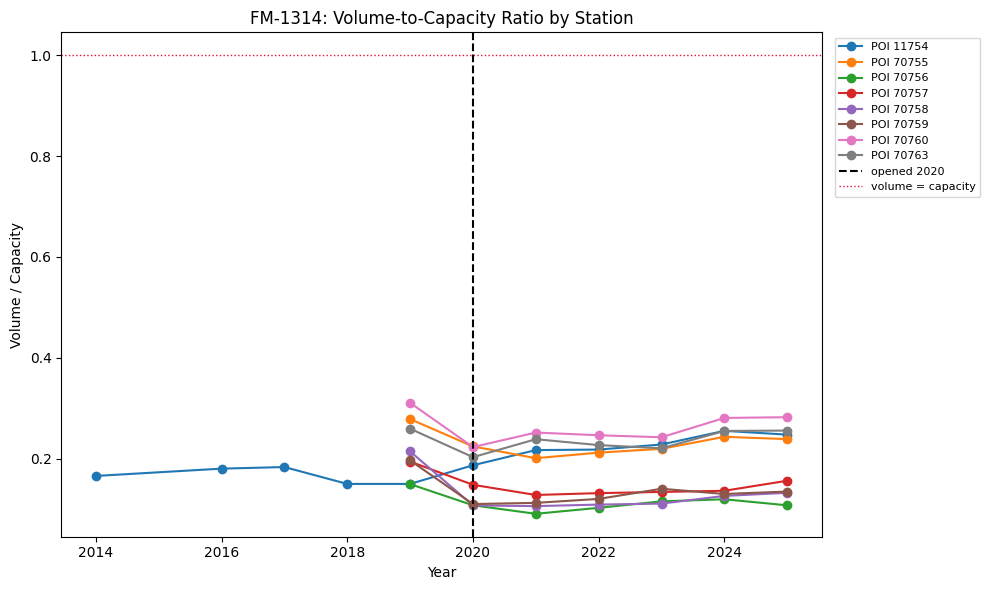

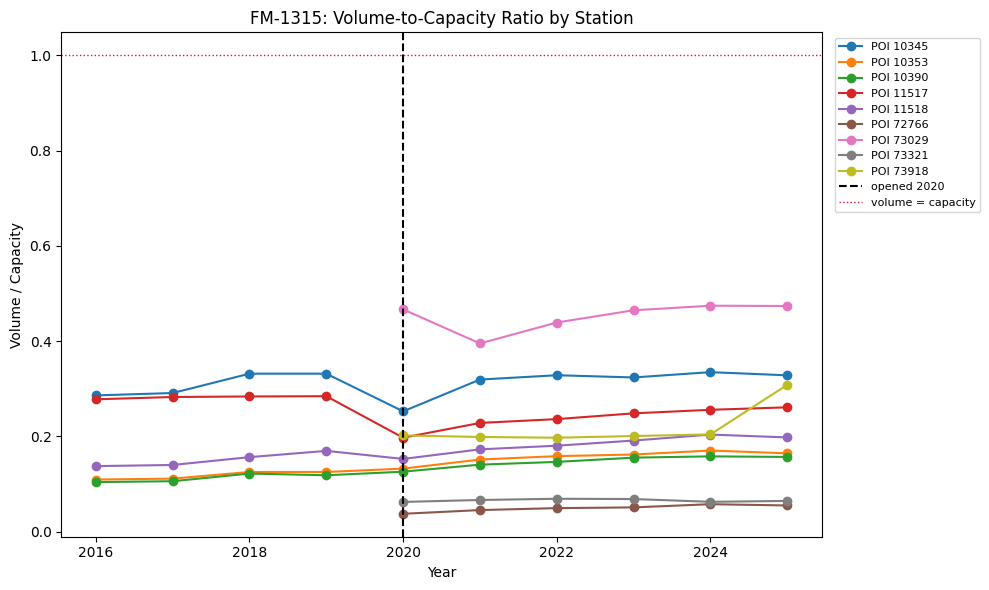

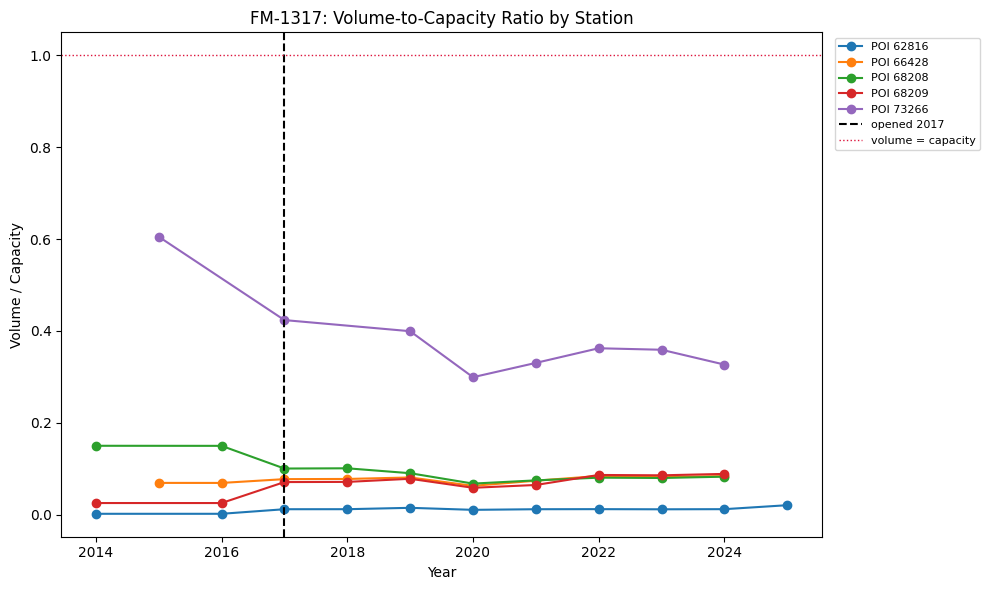

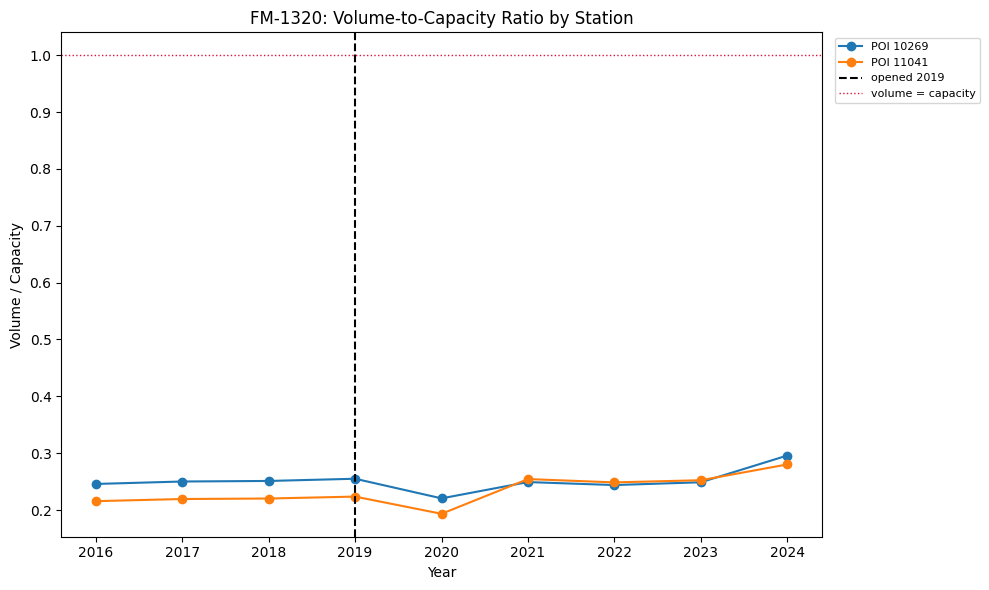

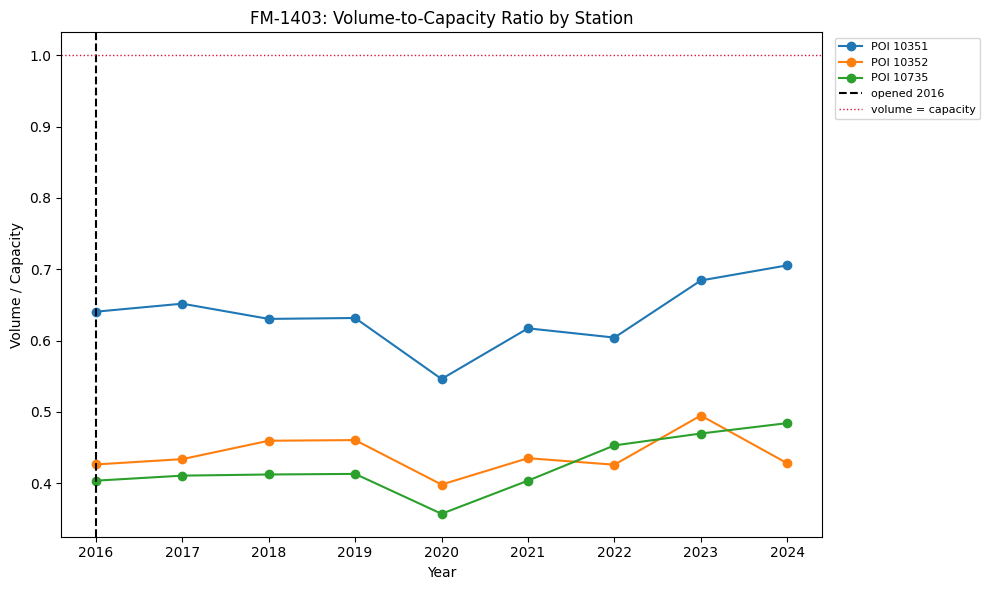

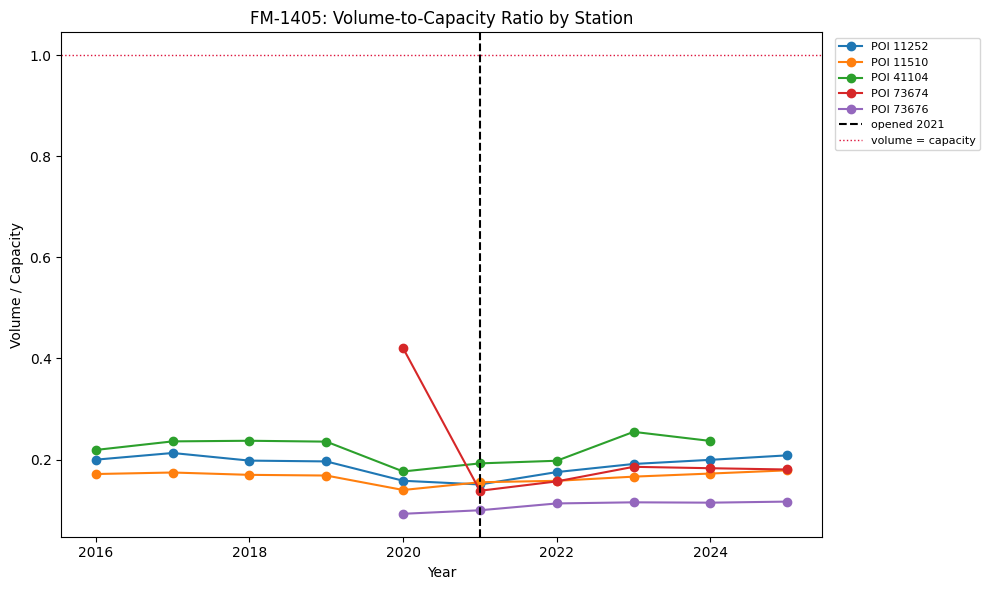

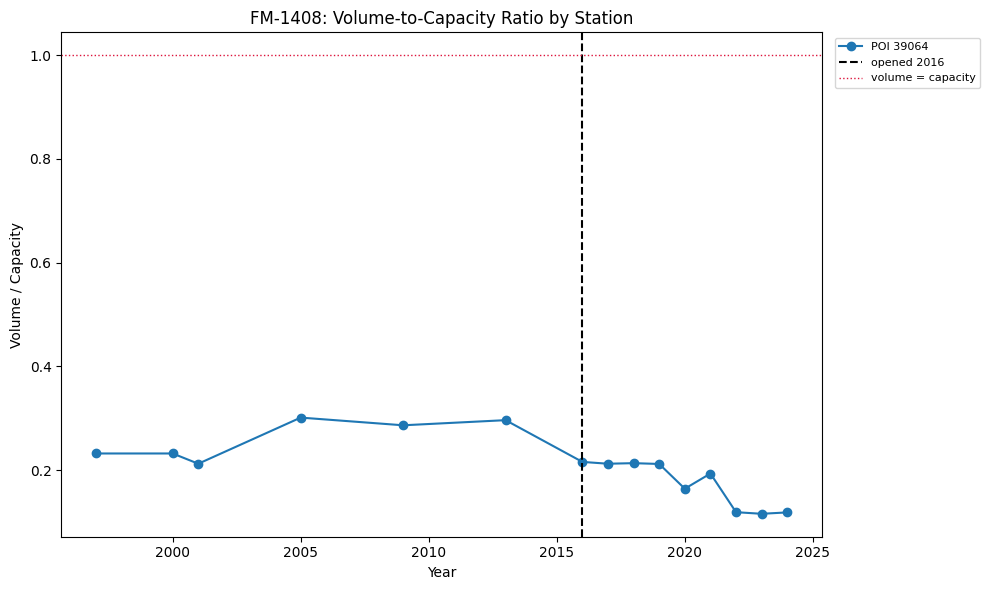

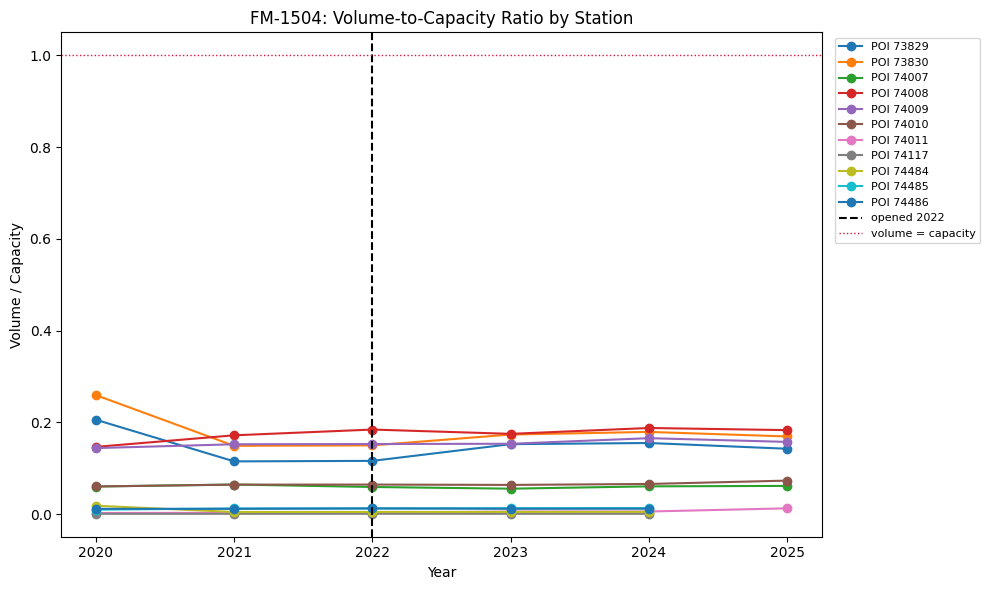

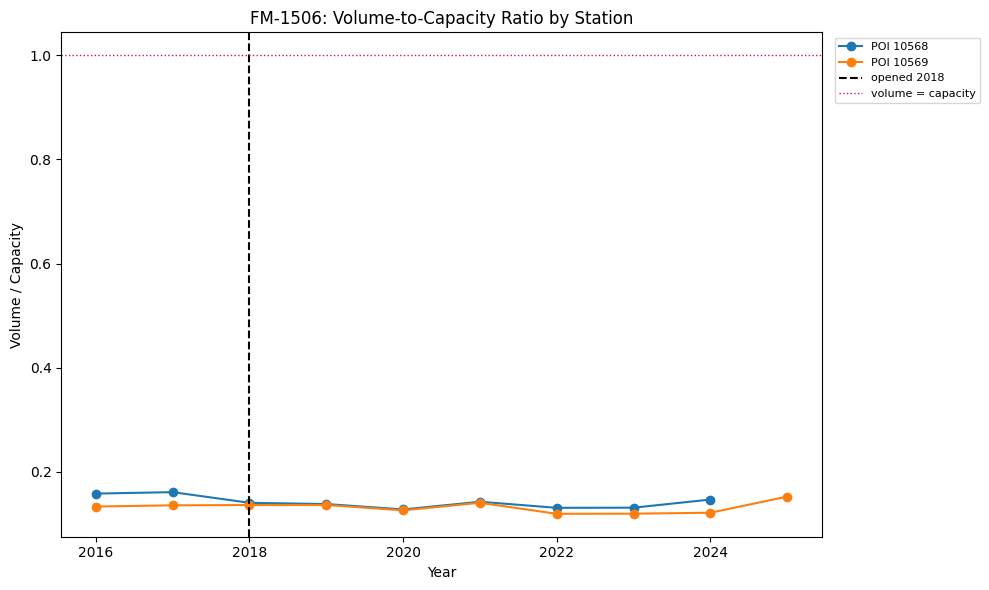

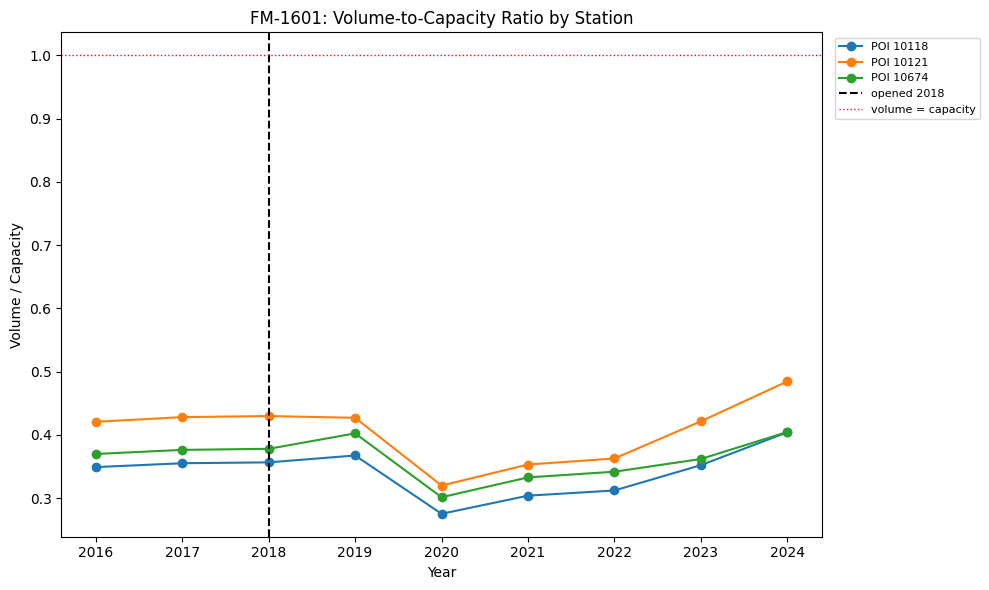

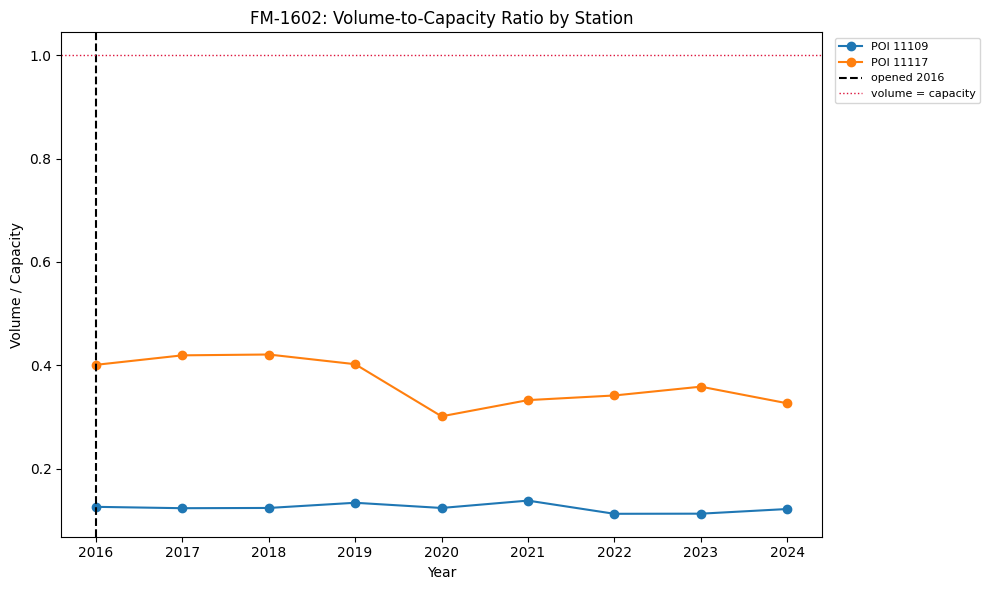

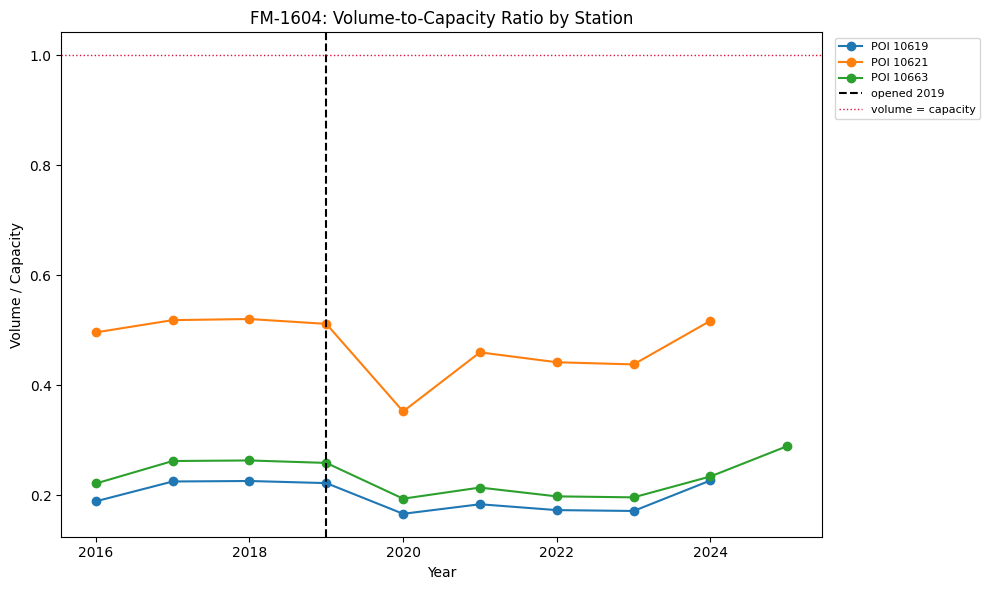

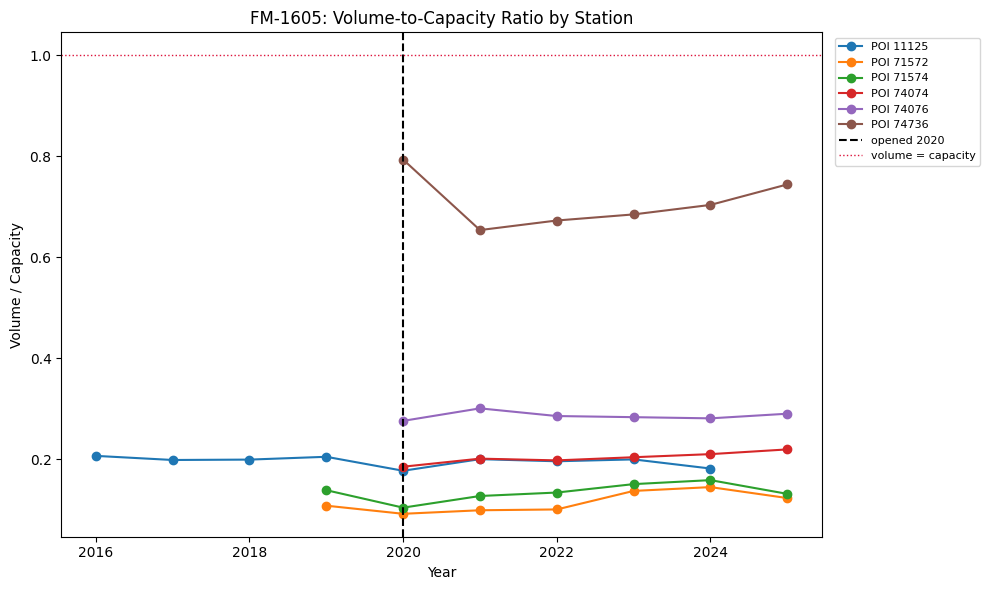

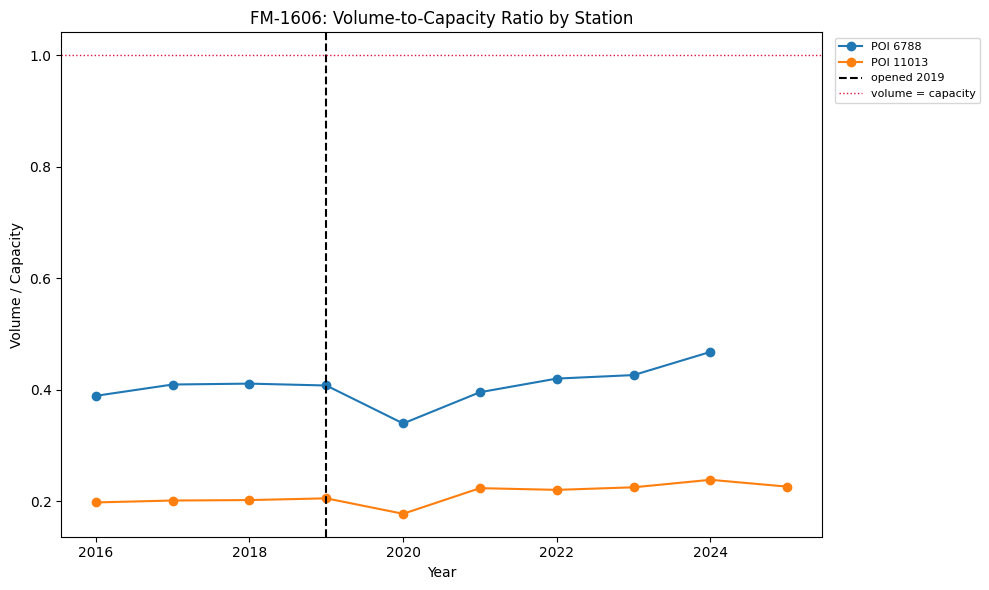

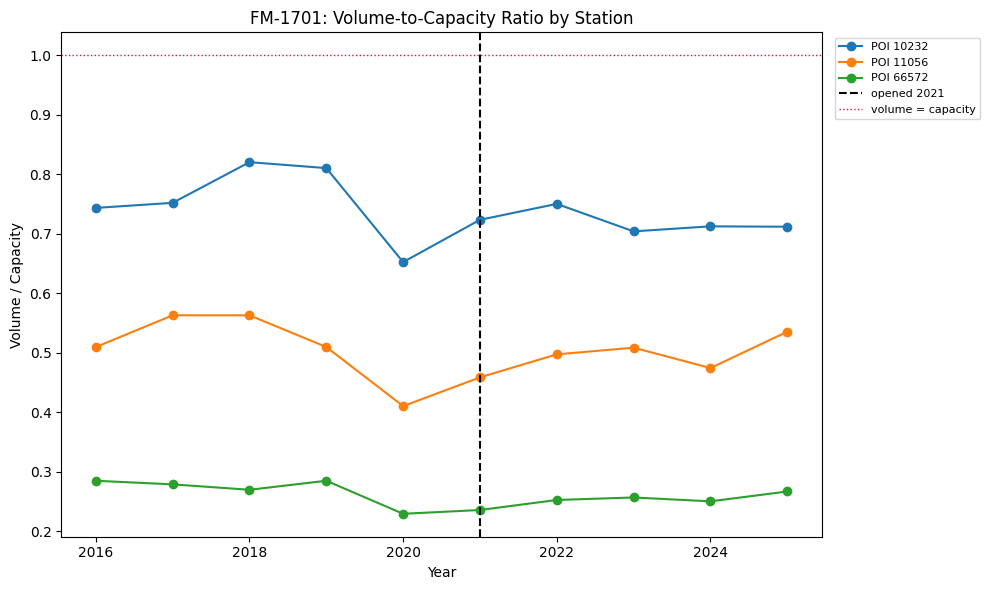

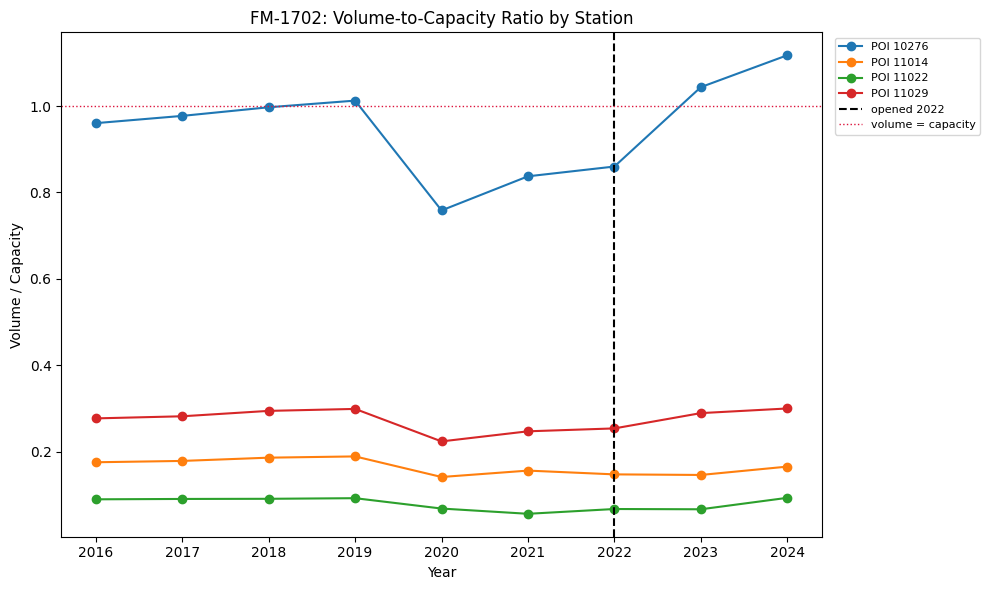

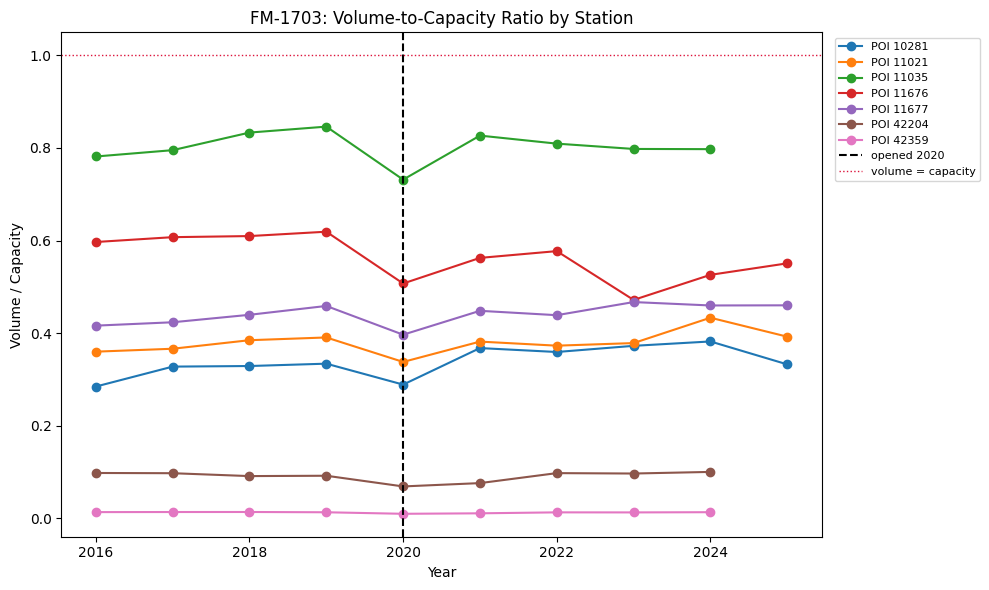

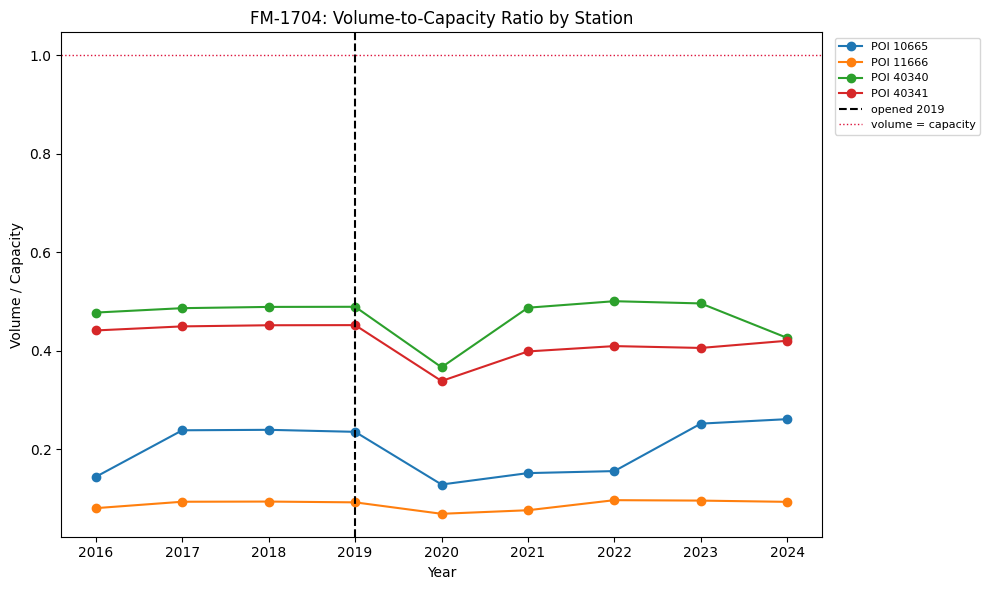

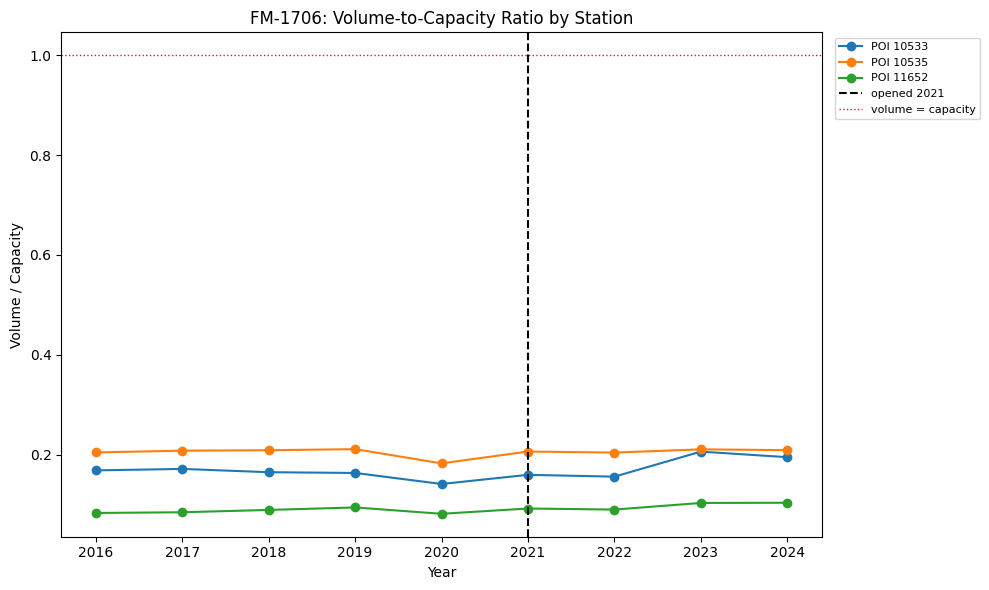

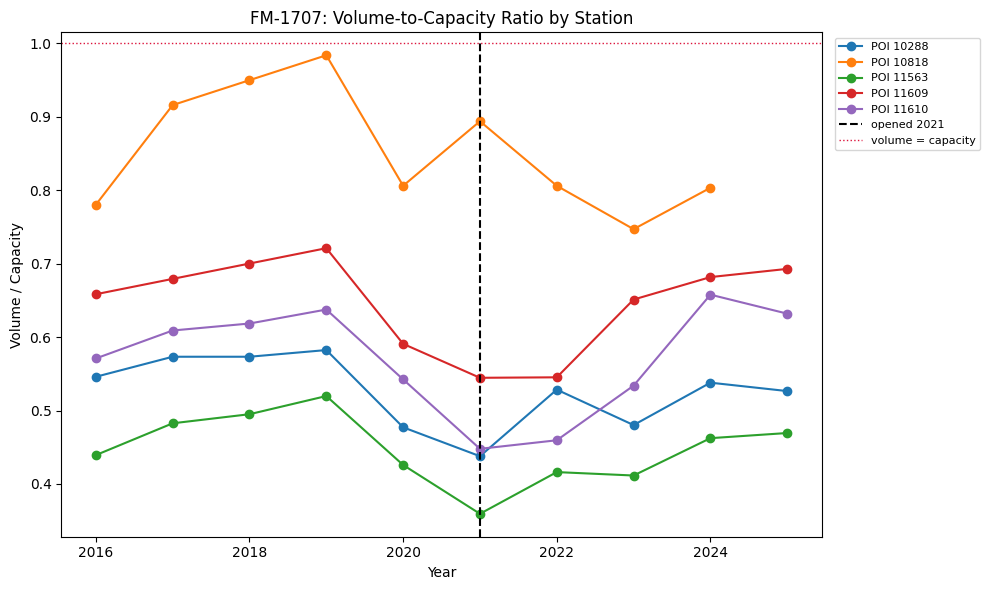

No usable volume/capacity data for FM-1803


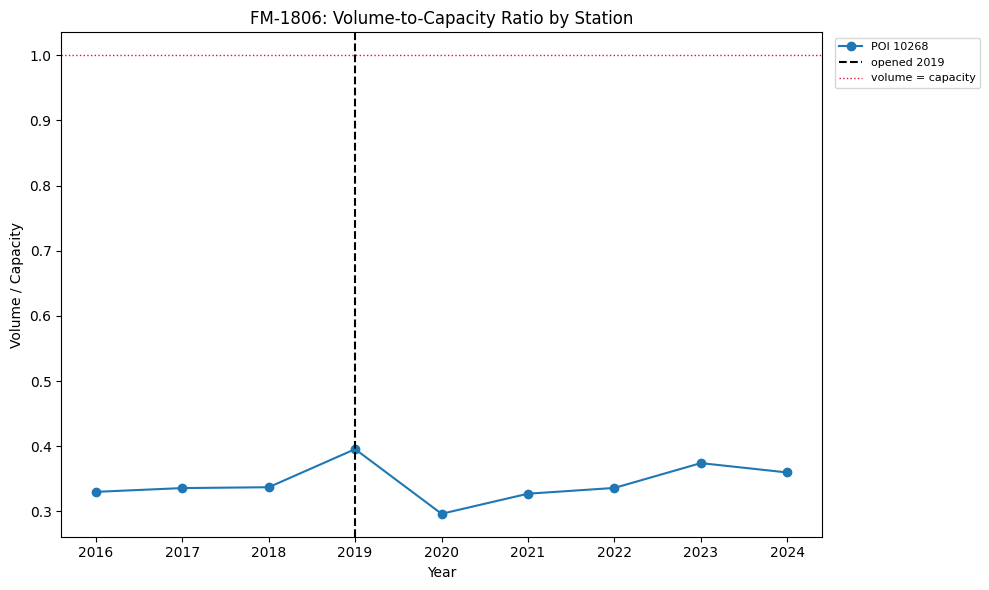

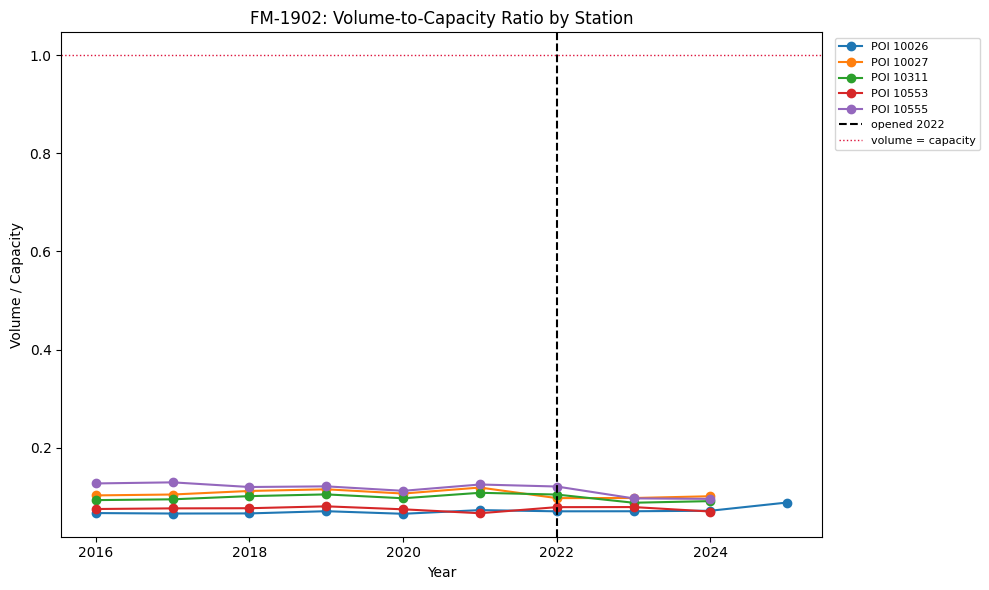

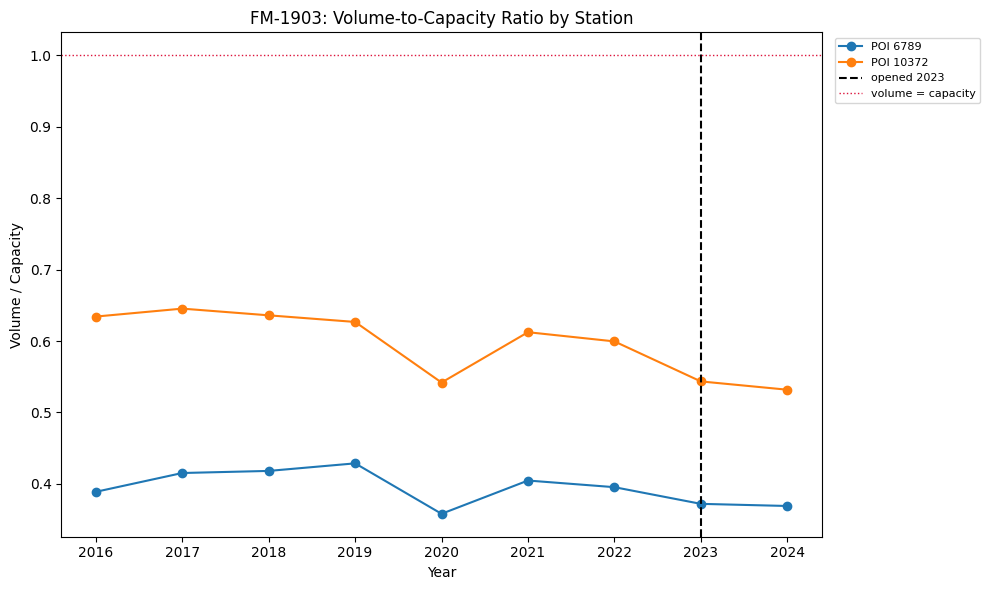

In [20]:
for pid in PROJECTS_TO_PLOT:
    fig, ax = plt.subplots(figsize=(10, 6))
    result = plot_project_vc_ratio(df, pid, ax=ax)
    if result is None:
        plt.close(fig)  # no usable volume/capacity data for this project - skip the chart
        continue
    plt.tight_layout()
    plt.show()
    plt.close(fig)